# Hackathon WorCAP 2026 — Equipe Nimbus PA

Este notebook reproduz duas soluções: a média de modelos LightGBM (score público informado **1,65183**) e sua combinação com regressão ridge local (**1,65354**). A execução produz, respectivamente, `componentes/media_arvores.csv` e `submission_hibrida.csv` e confere seus hashes originais.

A explicação abaixo descreve os componentes e a combinação completa. Consulte também `DADOS_EXTERNOS.md` e `NOTA_TEMPORAL.md` no pacote. **As fontes são retrospectivas; o alinhamento em T−1 não certifica a disponibilidade dos valores publicados naquela data, especialmente nos índices HadISST/NOAA.** A interpretação dessa condição está sujeita à análise da organização.


<div style="padding:30px;background:#12384b;color:white;border-radius:12px">
<div style="font-size:12px;letter-spacing:2px;color:#8fdbcd">WORCAP 2026 · MODELAGEM CLIMÁTICA</div>
<h1 style="color:white;margin-top:12px">Precipitação mensal na América do Sul</h1>
<p style="font-size:20px;color:#deedf2">Integração de previsões sazonais, árvores de decisão e regressão local regularizada</p>
<p style="color:#8fdbcd">Dados → climatologias → aprendizagem → validação temporal → previsão auditada</p>
</div>

## Visão geral

Esta solução prevê a **precipitação média diária de cada mês**, em **mm/dia**, em uma grade sobre a América do Sul. Combina o padrão climatológico de cada local com informações atmosféricas, índices oceânicos e previsões de dois sistemas sazonais: **SEAS5** e **CFSv2**.

A previsão reúne três componentes complementares: um LightGBM com SEAS5, outro LightGBM com SEAS5 e CFSv2 e uma regressão ridge que ajusta localmente as duas previsões sazonais. Os dois componentes de árvores recebem **37,5% cada** e a regressão recebe **25%**. Os pesos são fixos neste notebook.

| Evidência do modelo apresentado | Valor |
|---|---:|
| RMSE na validação temporal, 2007–2020 | **1,748951169 mm/dia** |
| MAE na validação temporal | **1,045834189 mm/dia** |
| Viés médio: previsto menos observado | **+0,011350132 mm/dia** |
| Score público de 2023, informado pelo participante | **1,65354** |
| Previsão final | **24 meses · 78.561 pontos · 1.885.464 registros** |

Os resultados históricos incorporados são registros auditados de execuções com dados reais. As células de treinamento permanecem sem saídas até serem executadas. O score público é informado pelo participante e não é recalculado aqui; o resultado privado não está disponível.

## Como executar no Kaggle

1. Importe este `.ipynb` em um notebook novo.
2. Em **Add Input**, anexe a competição e os datasets preparados **`worcap-seas5-dados`** e **`worcap-cfsv2-dados`**.
3. Cada dataset sazonal precisa conter seu manifesto JSON e os três NetCDFs: desenvolvimento, somente ajuste final e teste. Não é necessário anexar CSVs de previsões nem notebooks de outros experimentos.
4. Use CPU. O código incorpora o snapshot dos índices NOAA; não precisa de Internet, token ou novo download.
5. Execute **Run All**. Por padrão, os três componentes finais são ajustados novamente. Para refazer também toda a validação temporal, use `REEXECUTAR_VALIDACAO=True`.
6. O arquivo gerado será **`submission_hibrida.csv`**, em uma pasta nova de Output. A reprodução só é confirmada quando seu SHA-256 coincide com o arquivo documentado.

O ambiente de referência do treinamento das árvores é Python 3.12, NumPy 2.0.2, pandas 2.3.3, xarray 2025.12.0 e LightGBM 4.6.0. A execução verifica essas versões, sem alterá-las automaticamente.

In [ ]:
from pathlib import Path
import os, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# False: ajusta os três componentes finais e gera o CSV.
# True: também refaz a validação histórica dos três componentes nos sete blocos.
REEXECUTAR_VALIDACAO = False

# None procura os arquivos nos Inputs do Kaggle. Se necessário, informe as pastas.
BANCA_PASTA_DADOS = None
BANCA_PASTA_SEAS5 = None
BANCA_PASTA_CFSV2 = None
PASTA_FIGURAS_REFERENCIA = (Path('/kaggle/working/figuras_hibridas')
    if Path('/kaggle/input').is_dir() else Path.cwd()/'outputs/figuras_hibridas')

## 1. Definição do problema e organização temporal

Denotamos por $P_{T,g}$ a precipitação média diária no mês-alvo $T$ e ponto de grade $g$. A grade tem **301 latitudes × 261 longitudes**, espaçamento de **0,25°**, entre 60°S–15°N e 90°W–25°W. Cada saída corresponde a um mês inteiro: **não é uma previsão diária nem um acumulado mensal**.

| Informação | Ao prever fevereiro/2023 |
|---|---|
| Mês-alvo $T$ | Fevereiro/2023 |
| Atmosfera e índices oceânicos usados | Janeiro/2023, isto é, $T-1$ |
| Previsões sazonais | Previsão para fevereiro, inicializada antes desse mês |
| Último mês de chuva utilizado no ajuste final | Dezembro/2022 |

Os preditores acompanham o mês anterior a cada alvo, mas os modelos finais ficam congelados após o ajuste até dezembro/2022. Não há atualização com a chuva observada de 2023/2024. O campo `tp_ultima_obs` do teste não entra como chuva recente, pois sua informação permanece congelada em dezembro/2022.

Os arquivos oficiais de precipitação já estão em **mm/dia**. `treino_tp_alvo.nc` contém o deslocamento para o mês seguinte; a auditoria verifica essa relação antes de montar os pares por data. Aplicar outro deslocamento produziria um alvo temporal incorreto.

## 2. Dados e preparação

| Fonte | Conteúdo | Uso no modelo |
|---|---|---|
| Dados oficiais da competição | Chuva histórica, nove campos atmosféricos, calendário, grade e IDs | Ajuste dos modelos e contrato de exportação |
| NOAA PSL | Niño 3.4, Niño 1+2, TNA e TSA mensais | Estado oceânico de $T-1$, recentrado usando apenas o treino |
| ECMWF SEAS5, via C3S | Precipitação mensal prevista, sistema 51, `forecastMonth=2` | Média do ensemble e anomalia em relação ao próprio sistema |
| NCEP-CFSv2, via IRI | Precipitação prevista, `PENTAD_SAMPLES_FULL`, lead 1,5 | Média do ensemble e anomalia em relação ao próprio sistema |

As nove variáveis atmosféricas são cobertura de nuvens, geopotencial a 850 hPa, umidade relativa a 850 hPa, umidade específica a 850 hPa, pressão superficial, temperatura a 2 m, temperatura a 850 hPa e vento zonal e meridional a 850 hPa.

### Preparação espacial e unidades

As previsões sazonais são interpoladas bilinearmente para a grade oficial, com cobertura previamente conferida e **sem extrapolação**. A interpolação permite alinhar as fontes; não transforma a resolução física original dos modelos em resolução efetiva de 0,25°.

Na preparação SEAS5, a taxa de precipitação em m/s foi convertida para mm/dia multiplicando por **86.400.000**. A média dos membros utiliza a contagem efetivamente auditada, que varia entre 25 e 51. Pequenos valores negativos residuais, até 0,01 mm/dia em módulo, foram zerados por membro e registrados; valores além desse limite interrompem a preparação. Anomalias negativas são mantidas: elas significam chuva prevista abaixo da média do sistema.

O CFSv2 tem normalmente 24 ou 28 membros neste produto. A emissão de agosto/2019 tem 23: a indisponibilidade do membro 17 foi conferida nos campos individuais, registrada no manifesto e não foi preenchida artificialmente. As datas dos membros precisam anteceder o mês-alvo.

### Rastreabilidade

Os arquivos preparados separam desenvolvimento até 2020, dados de 2021–2022 para o ajuste final e previsões para 2023–2024. Cada entrada é verificada por SHA-256. O snapshot NOAA é incorporado ao código e exportado junto das fontes. Essa organização permite identificar exatamente quais dados produziram o resultado.

## 3. Climatologia: o padrão local de referência

Para cada ponto $g$ e mês do ano $m$, calcula-se a média da chuva nos **30 anos anteriores ao corte**, incluindo o último ano de treinamento:

$$C_{m,g}=\frac{1}{N_m}\sum_{t\in\mathcal T_m}P_{t,g}.$$

$\mathcal T_m$ contém apenas os meses de treino correspondentes ao mês do ano $m$. Janeiro é comparado com outros janeiros; julho, com outros julhos. Esse padrão representa a sazonalidade e as diferenças espaciais de precipitação.

As anomalias atmosféricas e oceânicas também são calculadas com referências mensais de treino. Para as previsões SEAS5 e CFSv2, subtrai-se a média mensal do **próprio sistema**, usando os meses disponíveis na janela de exemplos. Assim, uma anomalia sazonal mede quanto o sistema prevê acima ou abaixo de seu padrão local, sem incorporar a chuva futura.

Nos primeiros blocos, os exemplos e as referências dos sistemas sazonais começam em fevereiro/1982. As climatologias de chuva, atmosfera e NOAA mantêm 30 anos. No ajuste final, todas as referências e os exemplos cobrem janeiro/1993–dezembro/2022.

## 4. Dois componentes de árvores de decisão

### 4.1 Alvo residual e exclusão da própria observação

O LightGBM aprende o desvio da chuva em relação à climatologia. Para um exemplo de treino, a média de chuva exclui o valor desse próprio exemplo:

$$C^{(-T)}_{m,g}=\frac{\sum_{t\in\mathcal T_m}P_{t,g}-P_{T,g}}{N_m-1},\qquad r_{T,g}=P_{T,g}-C^{(-T)}_{m,g}.$$

Esse procedimento, chamado *leave-one-out*, é usado na feature climatológica e no alvo residual de treino. Na validação e na previsão final, utiliza-se a climatologia completa dos dados de treino; o valor observado do alvo previsto nunca entra nessa referência.

### 4.2 Variáveis de entrada

| Grupo de variáveis | Árvores com SEAS5 | Árvores com SEAS5 + CFSv2 |
|---|---:|---:|
| Campos atmosféricos em valor absoluto | 9 | 9 |
| Anomalias mensais dos campos atmosféricos | 9 | 9 |
| Latitude e longitude | 2 | 2 |
| Seno e cosseno do mês-alvo | 2 | 2 |
| Climatologia local da chuva | 1 | 1 |
| Índices oceânicos recentrados | 4 | 4 |
| SEAS5: média prevista e anomalia mensal | 2 | 2 |
| CFSv2: média prevista e anomalia mensal | 0 | 2 |
| **Total** | **29** | **31** |

O seno e o cosseno representam o ciclo anual sem criar uma ruptura artificial entre dezembro e janeiro. Os valores absolutos indicam o estado do sistema; as anomalias indicam quanto ele se afasta de seu padrão mensal.

### 4.3 Amostragem e aprendizagem

São selecionados **5.000 pontos sem reposição por mês**, com semente derivada de `[42, ano, mês]`. Os dois modelos recebem os mesmos pontos e alvos. Os 360 meses finais produzem **1.800.000 exemplos por componente**. A validação usa todos os pontos da grade.

Cada LightGBM é um modelo global, compartilhado entre pontos e meses. Ele combina sequencialmente árvores para reduzir o erro quadrático dos resíduos. As coordenadas e a sazonalidade permitem respostas diferentes conforme o local e o mês.

| Parâmetro | Configuração |
|---|---:|
| Árvores | 300 |
| Número máximo de folhas | 31 |
| Taxa de aprendizagem | 0,05 |
| Mínimo de exemplos por folha | 150 |
| Regularização L2 | 10 |
| Fração de variáveis por árvore | 0,9 |
| Fração de exemplos no bagging | 0,8 |
| Frequência do bagging | Toda iteração |
| Semente / threads CPU | 42 / 4 |

Usam-se `deterministic=True` e `force_col_wise=True`. Esses controles ajudam a reprodução, mas não substituem a conferência do ambiente e do arquivo final.

### 4.4 Reconstrução da chuva

Se $f_S$ e $f_{SC}$ são os resíduos previstos pelos componentes com um e dois sistemas sazonais:

$$P_S=\max(0,C+0{,}900f_S),\qquad P_{SC}=\max(0,C+0{,}875f_{SC}).$$

Os fatores 0,900 e 0,875 moderam a amplitude das correções. Foram definidos utilizando a validação histórica de desenvolvimento e permanecem fixos nesta reprodução. O truncamento garante precipitação não negativa e ocorre em cada componente antes da combinação.

## 5. Componente de regressão local regularizada

As árvores representam relações não lineares e interações entre variáveis. A regressão acrescenta uma estrutura mais simples: **em cada ponto da grade, dois coeficientes combinam as anomalias previstas por SEAS5 e CFSv2**. Há um ajuste por ponto, com coeficientes compartilhados pelos 12 meses; não são 12 regressões independentes.

### 5.1 Centralização e escala

Para as datas de treino disponíveis, subtraem-se as médias mensais de SEAS5, CFSv2 e chuva. Em seguida, cada anomalia preditora é dividida por seu desvio-padrão no treino, agrupando todos os meses. Isso coloca os dois preditores numa escala comparável para aplicar a regularização.

Denote por $x_{t,g}$ o vetor de duas anomalias padronizadas e por $y_{t,g}$ a anomalia de chuva, calculada nessa mesma janela de exemplos. A regressão não utiliza as outras variáveis atmosféricas nem os índices NOAA diretamente.

### 5.2 Função de ajuste

$$\hat\beta_g=\arg\min_{\beta_g}\left[\frac{1}{n}\sum_{t=1}^{n}(y_{t,g}-x_{t,g}^{\mathsf T}\beta_g)^2+0{,}1\|\beta_g\|_2^2\right].$$

A penalização ridge limita coeficientes excessivos quando os sistemas são correlacionados ou há poucos anos. O valor **0,1** é fixo. Na convenção de soma de erros de `sklearn.linear_model.Ridge`, corresponde a `alpha=0.1*n`. Não há busca de regularização nem de pesos neste notebook.

A solução usa o sistema linear de ordem 2:

$$\hat\beta_g=(X_g^{\mathsf T}X_g/n+0{,}1I)^{-1}X_g^{\mathsf T}y_g/n.$$

O código calcula sua forma fechada em **float64**, por grupos de pontos, sem treinamento iterativo. Coeficientes de qualquer sinal são permitidos. Os desvios-padrão são incorporados aos coeficientes salvos para que a inferência utilize as anomalias em suas unidades originais.

### 5.3 Previsão local

$$P_R(T,g)=\max\left[0,C_{m(T),g}+b_{S,g}(S_{T,g}-\bar S_{m(T),g})+b_{C,g}(F_{T,g}-\bar F_{m(T),g})\right].$$

$S$ representa SEAS5; $F$, CFSv2. A chuva usada para ajustar os coeficientes é centrada na janela comum dos exemplos, enquanto a reconstrução adiciona a climatologia de chuva de 30 anos. Essa distinção importa nos primeiros blocos, em que a janela sazonal tem menos de 30 anos. No ajuste final, ambas cobrem os mesmos 30 anos.

A regressão usa **todos os pontos e meses de treino**. Em cada ponto, porém, existem no máximo 360 observações temporais para estimar dois coeficientes: o número de pixels não aumenta o tamanho temporal de cada regressão.

## 6. Combinação dos componentes

Em precisão matemática, a combinação é:

$$\boxed{\hat P=0{,}375P_S+0{,}375P_{SC}+0{,}25P_R.}$$

A motivação é combinar estruturas com erros parcialmente diferentes. A regressão pode contribuir para a mistura mesmo sem superar individualmente os componentes de árvores. Isso é verificado no resultado conjunto, não presumido a partir da arquitetura.

Os pesos externos foram fixados antes da avaliação dessa combinação e não variam por ano, mês ou região. A reprodução mantém a **ordem exata de arredondamento** do arquivo documentado:

1. Exportar cada componente de árvores com seis casas decimais.
2. Reler os dois CSVs, calcular a média 50/50 em float64 e exportá-la com seis casas.
3. Reler essa média, combinar 75% dela com 25% da regressão ainda em float64.
4. Exportar a solução híbrida com seis casas decimais, na ordem do `sample_submission.csv`.

Esses arredondamentos têm efeito numérico muito pequeno, mas sua ordem é necessária para reproduzir os mesmos bytes do CSV. Na validação histórica, a combinação é calculada diretamente sobre as previsões dos componentes, antes desses arredondamentos de exportação.

## 7. Validação temporal

O protocolo utiliza **sete blocos de dois anos**. Cada ajuste termina em dezembro e prevê os 24 meses seguintes. O treinamento não incorpora os alvos do bloco de validação. Climatologias, escalas e coeficientes são estimados novamente dentro de cada treino.

O início de exemplos é o mais recente entre fevereiro/1982 e o início dos últimos 30 anos. A climatologia de chuva, atmosfera e NOAA mantém 30 anos. A última linha da figura mostra o ajuste final, sem avaliar a precipitação de 2023/2024 neste notebook.

In [ ]:
BANCA_REF=json.loads('{"entradas": [{"nome": "treino_tp.nc", "sha256": "012bebbe0e38aefdf4f9e2432c3ca22f71d94ea1a1b5421da9d9e5048632cab0", "bytes": 186685299}, {"nome": "treino_tp_alvo.nc", "sha256": "915f67f2627e37399830d1dd92b209ce1160082b0645662675eab17df957abe4", "bytes": 186509303}, {"nome": "teste_features.nc", "sha256": "70bcb5c9bb9c011c8901660834b42dc57ff7e54a4f34161d489ec5e9f05c1f23", "bytes": 39057097}, {"nome": "sample_submission.csv", "sha256": "34fe449ddb309b0579a87786f76049863833d82c26f183d18e943dc76f1e4c8c", "bytes": 48145117}, {"nome": "treino_cloud_cover.nc", "sha256": "607ee1210615a0ca8a5c954737617e668a5f016eb881554cb1468fda74b4fde1", "bytes": 190610590}, {"nome": "treino_geopotential_850.nc", "sha256": "ca3baca0177e2e90b42901803f348a4b4affe88bee202b76af3f293fa7035c17", "bytes": 159707312}, {"nome": "treino_rel_hum_850.nc", "sha256": "90f62b44b1b461259e7539249914e26cf09993f3bcd572ba4871931e45264b19", "bytes": 180398147}, {"nome": "treino_shum_850.nc", "sha256": "35cf8071b68d1e924ad87e0f8bd801d0a66d1d78ae75fc3cb623bde85c3f47bb", "bytes": 175651693}, {"nome": "treino_surface_pressure.nc", "sha256": "f00a5e44a03ea923ac0f693b975ef71cd347f8ad3d07692c602e3ac9a25c10fb", "bytes": 160228025}, {"nome": "treino_t2.nc", "sha256": "7d8c53b438289cddf87a11414ad10c8167f52ff33c6eff459a3288975079ef23", "bytes": 175952066}, {"nome": "treino_temperature_850.nc", "sha256": "1db7b4fdeba87b6a25f7fb6f1e40abec50964234dd9cc918cd34f902b8e41bac", "bytes": 172474226}, {"nome": "treino_u_850.nc", "sha256": "73c898f27bea25cf2ab0914bbe5c29acc9794a93f8b6b3affa39854bebccf761", "bytes": 188451602}, {"nome": "treino_v_850.nc", "sha256": "7bab583972e5718bb0e0fe0fe6a056bd56c968af1f1497205182f7621e26c241", "bytes": 197354831}], "hash_manifesto_SEAS5": "c7ce3a54f9a6f16189f5732ce12898ad42e1128de1a9395170c50b97718a45a9", "hash_manifesto_CFSv2": "02423b1016bae9c90314d7aea1cab6b374d09c010c226f635576d7f79f42d196", "csv_hashes": {"arvores_seas5": "6b0576902a4082ece1ab224ebfbab9f654f200a63aafaf7ed35fffb611f49cb7", "arvores_multissistema": "e52f577876bb190e19b246d87dab6cf1ed7a667635e397d4dda3eebdb6e0a0fd", "ensemble_arvores": "d06e2968e3cd6cc64e2afe92d1f51a3b32554da67bf8bdfb32a7dc50f46edc66"}, "nomes_csv": {"arvores_seas5": "componente_arvores_seas5.csv", "arvores_multissistema": "componente_arvores_multissistema.csv", "ensemble_arvores": "media_arvores.csv"}, "hash_solucao": "e98e8954debb8f7c764665a31804ec5512a1c2578c1ed4a24e50c51dedfb429b", "score_publico_informado": 1.65354, "resultado_privado_disponivel": false, "global_": [{"modelo": "arvores_seas5", "sse": 40704073.6450186, "n": 13198248, "soma_erro": 281424.1314378258, "soma_erro_absoluto": 13886391.634253746, "rmse": 1.7561467138368176, "mae": 1.0521390137731725, "vies": 0.021322840079821638}, {"modelo": "arvores_multissistema", "sse": 40612163.663067214, "n": 13198248, "soma_erro": 211225.40312294915, "soma_erro_absoluto": 13854292.438685479, "rmse": 1.7541628997367622, "mae": 1.049706933729801, "vies": 0.016004048652741572}, {"modelo": "ensemble_arvores", "sse": 40573178.49420618, "n": 13198248, "soma_erro": 246324.76728038743, "soma_erro_absoluto": 13852893.59150173, "rmse": 1.7533207535638786, "mae": 1.0496009463908944, "vies": 0.0186634443662816}, {"modelo": "ridge_local", "sse": 40838227.17360012, "n": 13198248, "soma_erro": -139766.8514354038, "soma_erro_absoluto": 13840800.48104592, "rmse": 1.7590383099097764, "mae": 1.0486846800458605, "vies": -0.0105898033917383}, {"modelo": "solucao_hibrida", "sse": 40371199.46926706, "n": 13198248, "soma_erro": 149801.86260143964, "soma_erro_absoluto": 13803178.990510795, "rmse": 1.7489511692458355, "mae": 1.045834188788603, "vies": 0.0113501324267766}], "blocos": [{"modelo": "arvores_seas5", "bloco": "A", "sse": 5757618.257861855, "n": 1885464, "soma_erro": 78766.20428908023, "soma_erro_absoluto": 1990574.0000364864, "rmse": 1.7474803910529724, "mae": 1.0557475507548733, "vies": 0.04177550156835677}, {"modelo": "arvores_seas5", "bloco": "B", "sse": 6142591.530513608, "n": 1885464, "soma_erro": -70490.66217144951, "soma_erro_absoluto": 2016777.2607466956, "rmse": 1.8049563181385055, "mae": 1.069645063892334, "vies": -0.03738637394903828}, {"modelo": "arvores_seas5", "bloco": "C", "sse": 5710557.580182263, "n": 1885464, "soma_erro": 317424.8757785753, "soma_erro_absoluto": 1950340.412061201, "rmse": 1.740324103233585, "mae": 1.0344087248874552, "vies": 0.16835371864887122}, {"modelo": "arvores_seas5", "bloco": "H1", "sse": 5629566.908650834, "n": 1885464, "soma_erro": -35765.253839950194, "soma_erro_absoluto": 1949580.0074536186, "rmse": 1.7279388543627885, "mae": 1.0340054264911016, "vies": -0.01896894018658017}, {"modelo": "arvores_seas5", "bloco": "H2", "sse": 6199065.437346904, "n": 1885464, "soma_erro": 14130.079987936304, "soma_erro_absoluto": 2072430.8583887792, "rmse": 1.8132345600601598, "mae": 1.0991622531052192, "vies": 0.007494218923265734}, {"modelo": "arvores_seas5", "bloco": "H3", "sse": 5814257.225487892, "n": 1885464, "soma_erro": -62404.38917499641, "soma_erro_absoluto": 2006050.2404905227, "rmse": 1.75605453229139, "mae": 1.0639557374155766, "vies": -0.03309762964182631}, {"modelo": "arvores_seas5", "bloco": "H4", "sse": 5450416.704975246, "n": 1885464, "soma_erro": 39763.27656863007, "soma_erro_absoluto": 1900638.8550764432, "rmse": 1.7002223905260618, "mae": 1.0080483398656475, "vies": 0.021089385195702526}, {"modelo": "arvores_multissistema", "bloco": "A", "sse": 5726509.799101377, "n": 1885464, "soma_erro": 42531.18600589913, "soma_erro_absoluto": 1982282.2519748032, "rmse": 1.742753171646917, "mae": 1.0513498279334972, "vies": 0.02255741080492607}, {"modelo": "arvores_multissistema", "bloco": "B", "sse": 6126723.854904317, "n": 1885464, "soma_erro": -65301.40172611439, "soma_erro_absoluto": 2011272.5599247967, "rmse": 1.8026235094781504, "mae": 1.0667255168620544, "vies": -0.03463412811176156}, {"modelo": "arvores_multissistema", "bloco": "C", "sse": 5710154.963315289, "n": 1885464, "soma_erro": 331353.1822950011, "soma_erro_absoluto": 1950514.889425376, "rmse": 1.7402627522902836, "mae": 1.0345012630447339, "vies": 0.17574092228491295}, {"modelo": "arvores_multissistema", "bloco": "H1", "sse": 5620033.705676291, "n": 1885464, "soma_erro": -53010.78296004457, "soma_erro_absoluto": 1943175.2921538171, "rmse": 1.726475174133904, "mae": 1.0306085356993382, "vies": -0.028115510537482853}, {"modelo": "arvores_multissistema", "bloco": "H2", "sse": 6144316.455351737, "n": 1885464, "soma_erro": -36154.371027438436, "soma_erro_absoluto": 2058798.4596160767, "rmse": 1.8052097287248734, "mae": 1.0919319910727951, "vies": -0.019175317602159698}, {"modelo": "arvores_multissistema", "bloco": "H3", "sse": 5810140.558155263, "n": 1885464, "soma_erro": -51608.188886245014, "soma_erro_absoluto": 2001727.398716572, "rmse": 1.755432752749879, "mae": 1.0616630170168044, "vies": -0.027371611914226428}, {"modelo": "arvores_multissistema", "bloco": "H4", "sse": 5474284.326562942, "n": 1885464, "soma_erro": 43415.77942189132, "soma_erro_absoluto": 1906521.5868740368, "rmse": 1.703940999407519, "mae": 1.0111683844793837, "vies": 0.02302657564498252}, {"modelo": "ensemble_arvores", "bloco": "A", "sse": 5726372.535071534, "n": 1885464, "soma_erro": 60648.69514748968, "soma_erro_absoluto": 1983038.4503544085, "rmse": 1.7427322846873834, "mae": 1.0517508954583108, "vies": 0.0321664561866414}, {"modelo": "ensemble_arvores", "bloco": "B", "sse": 6127154.066696377, "n": 1885464, "soma_erro": -67896.03194878195, "soma_erro_absoluto": 2012428.843780457, "rmse": 1.8026867974845469, "mae": 1.0673387790912248, "vies": -0.0360102510303999}, {"modelo": "ensemble_arvores", "bloco": "C", "sse": 5700380.4091514, "n": 1885464, "soma_erro": 324389.0290367882, "soma_erro_absoluto": 1948340.9683552748, "rmse": 1.7387726370161405, "mae": 1.033348273080406, "vies": 0.172047320466892}, {"modelo": "ensemble_arvores", "bloco": "H1", "sse": 5614344.385637627, "n": 1885464, "soma_erro": -44388.01839999738, "soma_erro_absoluto": 1944375.977152655, "rmse": 1.7256010728856306, "mae": 1.0312453471149037, "vies": -0.0235422253620315}, {"modelo": "ensemble_arvores", "bloco": "H2", "sse": 6153236.228861352, "n": 1885464, "soma_erro": -11012.145519751066, "soma_erro_absoluto": 2061946.7586123731, "rmse": 1.806519575181048, "mae": 1.0936017651953966, "vies": -0.0058405493394469}, {"modelo": "ensemble_arvores", "bloco": "H3", "sse": 5799432.233518894, "n": 1885464, "soma_erro": -57006.28903062071, "soma_erro_absoluto": 2001193.5410003816, "rmse": 1.7538143398347998, "mae": 1.0613798730712345, "vies": -0.0302346207780263}, {"modelo": "ensemble_arvores", "bloco": "H4", "sse": 5452258.635269001, "n": 1885464, "soma_erro": 41589.52799526069, "soma_erro_absoluto": 1901569.0522461808, "rmse": 1.70050965540489, "mae": 1.0085416917247854, "vies": 0.0220579804203425}, {"modelo": "ridge_local", "bloco": "A", "sse": 5743727.36423542, "n": 1885464, "soma_erro": -46106.430935581455, "soma_erro_absoluto": 1979412.3010027115, "rmse": 1.745371122793437, "mae": 1.0498276822059247, "vies": -0.0244536257046442}, {"modelo": "ridge_local", "bloco": "B", "sse": 6146852.5760870045, "n": 1885464, "soma_erro": -123019.60798075733, "soma_erro_absoluto": 2010890.7781060385, "rmse": 1.8055822483964343, "mae": 1.066523029931114, "vies": -0.0652463308664378}, {"modelo": "ridge_local", "bloco": "C", "sse": 5731133.528950677, "n": 1885464, "soma_erro": 257839.82411186103, "soma_erro_absoluto": 1939253.157516151, "rmse": 1.7434566013306216, "mae": 1.028528339716988, "vies": 0.1367513906984493}, {"modelo": "ridge_local", "bloco": "H1", "sse": 5826616.701038214, "n": 1885464, "soma_erro": -59697.58963312057, "soma_erro_absoluto": 1965970.5823713716, "rmse": 1.7579199804780454, "mae": 1.0426985518532157, "vies": -0.0316620150971435}, {"modelo": "ridge_local", "bloco": "H2", "sse": 6073712.98068559, "n": 1885464, "soma_erro": -91262.51858077258, "soma_erro_absoluto": 2039564.302277744, "rmse": 1.7948080560284605, "mae": 1.0817307051620946, "vies": -0.0484032145831331}, {"modelo": "ridge_local", "bloco": "H3", "sse": 5779558.098208056, "n": 1885464, "soma_erro": -45494.03095323078, "soma_erro_absoluto": 1999443.843320139, "rmse": 1.7508066784742586, "mae": 1.0604518799192872, "vies": -0.0241288250283382}, {"modelo": "ridge_local", "bloco": "H4", "sse": 5536625.924395165, "n": 1885464, "soma_erro": -32026.49746380217, "soma_erro_absoluto": 1906265.5164517632, "rmse": 1.7136158426684127, "mae": 1.0110325715323991, "vies": -0.0169860031609206}, {"modelo": "solucao_hibrida", "bloco": "A", "sse": 5675537.182760052, "n": 1885464, "soma_erro": 33959.913626721886, "soma_erro_absoluto": 1971821.4770654023, "rmse": 1.7349795664960586, "mae": 1.0458017109132831, "vies": 0.0180114357138199}, {"modelo": "solucao_hibrida", "bloco": "B", "sse": 6103228.284507711, "n": 1885464, "soma_erro": -81676.92595677578, "soma_erro_absoluto": 2006961.593073176, "rmse": 1.7991637198354675, "mae": 1.064439094606514, "vies": -0.0433192709894093}, {"modelo": "solucao_hibrida", "bloco": "C", "sse": 5682150.009722237, "n": 1885464, "soma_erro": 307751.72780555644, "soma_erro_absoluto": 1940960.49819674, "rmse": 1.7359900241204849, "mae": 1.0294338678419424, "vies": 0.1632233380247814}, {"modelo": "solucao_hibrida", "bloco": "H1", "sse": 5628813.872793695, "n": 1885464, "soma_erro": -48215.41120827819, "soma_erro_absoluto": 1943429.453026784, "rmse": 1.727823282112394, "mae": 1.0307433358721163, "vies": -0.0255721727958095}, {"modelo": "solucao_hibrida", "bloco": "H2", "sse": 6081580.547496217, "n": 1885464, "soma_erro": -31074.738785006448, "soma_erro_absoluto": 2048006.0882079003, "rmse": 1.7959701295798205, "mae": 1.086208004081701, "vies": -0.0164812156503685}, {"modelo": "solucao_hibrida", "bloco": "H3", "sse": 5755652.240295366, "n": 1885464, "soma_erro": -54128.22451127322, "soma_erro_absoluto": 1994552.9286507545, "rmse": 1.747182015029822, "mae": 1.0578578687531317, "vies": -0.0287081718406043}, {"modelo": "solucao_hibrida", "bloco": "H4", "sse": 5444237.331691784, "n": 1885464, "soma_erro": 23185.521630494968, "soma_erro_absoluto": 1897446.9522900388, "rmse": 1.6992583093430695, "mae": 1.0063554394515295, "vies": 0.0122969845250267}], "anos": [{"modelo": "arvores_seas5", "ano": 2007, "sse": 2827373.2793338457, "n": 942732, "soma_erro": 31522.463643147494, "soma_erro_absoluto": 972179.6816828715, "rmse": 1.731798862929647, "mae": 1.0312365356038318, "vies": 0.03343735403396458}, {"modelo": "arvores_seas5", "ano": 2008, "sse": 2802193.629316989, "n": 942732, "soma_erro": -67287.71748309769, "soma_erro_absoluto": 977400.3257707469, "rmse": 1.7240702036717515, "mae": 1.0367743173783714, "vies": -0.07137523440712491}, {"modelo": "arvores_seas5", "ano": 2009, "sse": 3164886.1709787976, "n": 942732, "soma_erro": -77555.33456305263, "soma_erro_absoluto": 1038926.4548224859, "rmse": 1.832250812118275, "mae": 1.1020379650022338, "vies": -0.0822665768882913}, {"modelo": "arvores_seas5", "ano": 2010, "sse": 3034179.2663681055, "n": 942732, "soma_erro": 91685.41455098893, "soma_erro_absoluto": 1033504.4035662934, "rmse": 1.7940167505029165, "mae": 1.0962865412082048, "vies": 0.09725501473482276}, {"modelo": "arvores_seas5", "ano": 2011, "sse": 2897356.974887541, "n": 942732, "soma_erro": -85441.45781821967, "soma_erro_absoluto": 988007.8060740724, "rmse": 1.7531007633046456, "mae": 1.0480261687033774, "vies": -0.09063175729498911}, {"modelo": "arvores_seas5", "ano": 2012, "sse": 2916900.2506003506, "n": 942732, "soma_erro": 23037.06864322326, "soma_erro_absoluto": 1018042.4344164503, "rmse": 1.759003341231316, "mae": 1.0798853061277758, "vies": 0.024436498011336478}, {"modelo": "arvores_seas5", "ano": 2013, "sse": 2758737.7134548235, "n": 942732, "soma_erro": 48879.23669161415, "soma_erro_absoluto": 971688.8751636683, "rmse": 1.7106496839786258, "mae": 1.030715914134312, "vies": 0.051848496382443945}, {"modelo": "arvores_seas5", "ano": 2014, "sse": 2691678.9915204225, "n": 942732, "soma_erro": -9115.960122984077, "soma_erro_absoluto": 928949.9799127749, "rmse": 1.6897307516868298, "mae": 0.9853807655969828, "vies": -0.009669725991038892}, {"modelo": "arvores_seas5", "ano": 2015, "sse": 2755218.7006806848, "n": 942732, "soma_erro": -17066.354017233243, "soma_erro_absoluto": 971327.0635747702, "rmse": 1.7095582937059017, "mae": 1.0303321236308625, "vies": -0.018103081275731854}, {"modelo": "arvores_seas5", "ano": 2016, "sse": 3002399.55718117, "n": 942732, "soma_erro": 95832.55830631347, "soma_erro_absoluto": 1019246.9364617163, "rmse": 1.7845968381263777, "mae": 1.0811629778788843, "vies": 0.10165408441244539}, {"modelo": "arvores_seas5", "ano": 2017, "sse": 2809435.6778537105, "n": 942732, "soma_erro": -67130.74396668258, "soma_erro_absoluto": 994416.8736045046, "rmse": 1.7262966278615859, "mae": 1.0548245669018392, "vies": -0.0712087252439533}, {"modelo": "arvores_seas5", "ano": 2018, "sse": 3333155.852659898, "n": 942732, "soma_erro": -3359.918204766931, "soma_erro_absoluto": 1022360.387142191, "rmse": 1.8803283153241983, "mae": 1.0844655608828289, "vies": -0.003564022654123262}, {"modelo": "arvores_seas5", "ano": 2019, "sse": 2711174.062014533, "n": 942732, "soma_erro": 136227.3182446313, "soma_erro_absoluto": 937053.7538155135, "rmse": 1.6958388330928804, "mae": 0.9939768182426325, "vies": 0.1445026987994799}, {"modelo": "arvores_seas5", "ano": 2020, "sse": 2999383.5181677295, "n": 942732, "soma_erro": 181197.55753394403, "soma_erro_absoluto": 1013286.6582456874, "rmse": 1.7837002609086938, "mae": 1.0748406315322778, "vies": 0.19220473849826253}, {"modelo": "arvores_multissistema", "ano": 2007, "sse": 2808496.6390779424, "n": 942732, "soma_erro": 32969.95570887299, "soma_erro_absoluto": 968856.9440868967, "rmse": 1.7260081010650719, "mae": 1.0277119521633897, "vies": 0.03497277668401305}, {"modelo": "arvores_multissistema", "ano": 2008, "sse": 2811537.066598349, "n": 942732, "soma_erro": -85980.73866891756, "soma_erro_absoluto": 974318.3480669205, "rmse": 1.726942120876995, "mae": 1.0335051192352869, "vies": -0.09120379775897876}, {"modelo": "arvores_multissistema", "ano": 2009, "sse": 3165536.6150238817, "n": 942732, "soma_erro": -83840.30369360931, "soma_erro_absoluto": 1038675.4811816793, "rmse": 1.8324390835660596, "mae": 1.101771745503154, "vies": -0.08893333809991526}, {"modelo": "arvores_multissistema", "ano": 2010, "sse": 2978779.840327856, "n": 942732, "soma_erro": 47685.93266617088, "soma_erro_absoluto": 1020122.9784343974, "rmse": 1.7775633137487512, "mae": 1.0820922366424364, "vies": 0.05058270289559586}, {"modelo": "arvores_multissistema", "ano": 2011, "sse": 2873731.3028165177, "n": 942732, "soma_erro": -74007.09799345955, "soma_erro_absoluto": 980435.6428668052, "rmse": 1.7459385524856474, "mae": 1.039994020428717, "vies": -0.07850279612176053}, {"modelo": "arvores_multissistema", "ano": 2012, "sse": 2936409.2553387457, "n": 942732, "soma_erro": 22398.90910721454, "soma_erro_absoluto": 1021291.7558497668, "rmse": 1.7648758794312867, "mae": 1.0833320136048916, "vies": 0.023759572293307683}, {"modelo": "arvores_multissistema", "ano": 2013, "sse": 2772917.1660594363, "n": 942732, "soma_erro": 58680.869687815895, "soma_erro_absoluto": 973795.8595242708, "rmse": 1.715040276783712, "mae": 1.0329508911591743, "vies": 0.062245547714319546}, {"modelo": "arvores_multissistema", "ano": 2014, "sse": 2701367.1605035057, "n": 942732, "soma_erro": -15265.090265924577, "soma_erro_absoluto": 932725.7273497661, "rmse": 1.692768947001757, "mae": 0.9893858777995932, "vies": -0.01619239642435451}, {"modelo": "arvores_multissistema", "ano": 2015, "sse": 2750076.1069006375, "n": 942732, "soma_erro": -24580.628663500625, "soma_erro_absoluto": 969484.4145189462, "rmse": 1.7079621100663547, "mae": 1.0283775394480577, "vies": -0.02607382444162352}, {"modelo": "arvores_multissistema", "ano": 2016, "sse": 2976433.6922007394, "n": 942732, "soma_erro": 67111.81466939976, "soma_erro_absoluto": 1012797.8374558571, "rmse": 1.7768631531855403, "mae": 1.0743221164189367, "vies": 0.07118864605147567}, {"modelo": "arvores_multissistema", "ano": 2017, "sse": 2794379.119583591, "n": 942732, "soma_erro": -68276.15303533949, "soma_erro_absoluto": 989777.2435592015, "rmse": 1.7216645580947922, "mae": 1.049903093943137, "vies": -0.07242371430622858}, {"modelo": "arvores_multissistema", "ano": 2018, "sse": 3332344.7353207264, "n": 942732, "soma_erro": 2974.751309225103, "soma_erro_absoluto": 1021495.3163655952, "rmse": 1.8800995141871908, "mae": 1.083547939780972, "vies": 0.0031554580827054804}, {"modelo": "arvores_multissistema", "ano": 2019, "sse": 2693229.4114087466, "n": 942732, "soma_erro": 142099.12597450335, "soma_erro_absoluto": 935196.3179045501, "rmse": 1.6902173281001034, "mae": 0.9920065489498077, "vies": 0.15073120035652057}, {"modelo": "arvores_multissistema", "ano": 2020, "sse": 3016925.551906542, "n": 942732, "soma_erro": 189254.05632049777, "soma_erro_absoluto": 1015318.5715208258, "rmse": 1.788908683473825, "mae": 1.07699597713966, "vies": 0.20075064421330532}, {"modelo": "ensemble_arvores", "ano": 2007, "sse": 2812395.8371101967, "n": 942732, "soma_erro": 32246.209676010243, "soma_erro_absoluto": 969466.2286170248, "rmse": 1.7272058438341973, "mae": 1.0283582488098684, "vies": 0.0342050653589888}, {"modelo": "ensemble_arvores", "ano": 2008, "sse": 2801948.5485274307, "n": 942732, "soma_erro": -76634.22807600762, "soma_erro_absoluto": 974909.7485356298, "rmse": 1.7239948081456271, "mae": 1.034132445419939, "vies": -0.0812895160830518}, {"modelo": "ensemble_arvores", "ano": 2009, "sse": 3160425.284193124, "n": 942732, "soma_erro": -80697.81912833097, "soma_erro_absoluto": 1037870.008407498, "rmse": 1.830959083895405, "mae": 1.1009173427946628, "vies": -0.0855999574941032}, {"modelo": "ensemble_arvores", "ano": 2010, "sse": 2992810.944668228, "n": 942732, "soma_erro": 69685.6736085799, "soma_erro_absoluto": 1024076.7502048754, "rmse": 1.7817448706606478, "mae": 1.0862861875961305, "vies": 0.0739188588152093}, {"modelo": "ensemble_arvores", "ano": 2011, "sse": 2878593.203325508, "n": 942732, "soma_erro": -79724.27790583961, "soma_erro_absoluto": 982708.3322739068, "rmse": 1.747414854780835, "mae": 1.0424047685597888, "vies": -0.0845672767083748}, {"modelo": "ensemble_arvores", "ano": 2012, "sse": 2920839.0301933857, "n": 942732, "soma_erro": 22717.9888752189, "soma_erro_absoluto": 1018485.2087264744, "rmse": 1.7601905585792752, "mae": 1.0803549775826795, "vies": 0.024098035152322}, {"modelo": "ensemble_arvores", "ano": 2013, "sse": 2760670.519173013, "n": 942732, "soma_erro": 53780.05318971502, "soma_erro_absoluto": 971757.7969855976, "rmse": 1.711248830204026, "mae": 1.0307890227398642, "vies": 0.0570470220483817}, {"modelo": "ensemble_arvores", "ano": 2014, "sse": 2691588.116095988, "n": 942732, "soma_erro": -12190.525194454329, "soma_erro_absoluto": 929811.2552605828, "rmse": 1.6897022274282143, "mae": 0.9862943607097064, "vies": -0.0129310612076967}, {"modelo": "ensemble_arvores", "ano": 2015, "sse": 2745680.942839053, "n": 942732, "soma_erro": -20823.49134036693, "soma_erro_absoluto": 968894.4448650392, "rmse": 1.7065967341425248, "mae": 1.0277517309957012, "vies": -0.0220884528586776}, {"modelo": "ensemble_arvores", "ano": 2016, "sse": 2980691.592232481, "n": 942732, "soma_erro": 81472.18648785661, "soma_erro_absoluto": 1014144.0054893692, "rmse": 1.778133633672532, "mae": 1.0757500599209204, "vies": 0.0864213652319605}, {"modelo": "ensemble_arvores", "ano": 2017, "sse": 2797966.854683809, "n": 942732, "soma_erro": -67703.44850101104, "soma_erro_absoluto": 991256.8003916924, "rmse": 1.7227694359107468, "mae": 1.0514725291935485, "vies": -0.0718162197750909}, {"modelo": "ensemble_arvores", "ano": 2018, "sse": 3329187.212012568, "n": 942732, "soma_erro": -192.5834477709141, "soma_erro_absoluto": 1021172.0433887646, "rmse": 1.8792085702076688, "mae": 1.083205028988901, "vies": -0.0002042822857088}, {"modelo": "ensemble_arvores", "ano": 2019, "sse": 2697229.65049852, "n": 942732, "soma_erro": 139163.22210956732, "soma_erro_absoluto": 935097.3569729072, "rmse": 1.691472097678867, "mae": 0.9919015764532308, "vies": 0.1476169495780002}, {"modelo": "ensemble_arvores", "ano": 2020, "sse": 3003150.7586528813, "n": 942732, "soma_erro": 185225.8069272209, "soma_erro_absoluto": 1013243.6113823676, "rmse": 1.7848200775557126, "mae": 1.0747949697075814, "vies": 0.1964776913557839}, {"modelo": "ridge_local", "ano": 2007, "sse": 2888102.2585701453, "n": 942732, "soma_erro": -1919.409152320892, "soma_erro_absoluto": 971085.4754997342, "rmse": 1.7502986531195364, "mae": 1.030075859841115, "vies": -0.0020360072134189}, {"modelo": "ridge_local", "ano": 2008, "sse": 2938514.442468069, "n": 942732, "soma_erro": -57778.18048079968, "soma_erro_absoluto": 994885.1068716372, "rmse": 1.7655084084806285, "mae": 1.055321243865316, "vies": -0.061288022980868}, {"modelo": "ridge_local", "ano": 2009, "sse": 3139703.8804439, "n": 942732, "soma_erro": -68835.11464637515, "soma_erro_absoluto": 1035413.3135297172, "rmse": 1.824946849398968, "mae": 1.098311411440067, "vies": -0.0730166310747647}, {"modelo": "ridge_local", "ano": 2010, "sse": 2934009.100241689, "n": 942732, "soma_erro": -22427.40393439743, "soma_erro_absoluto": 1004150.9887480264, "rmse": 1.7641544469909949, "mae": 1.0651499988841224, "vies": -0.0237897980915015}, {"modelo": "ridge_local", "ano": 2011, "sse": 2897554.891618034, "n": 942732, "soma_erro": -76028.87666401574, "soma_erro_absoluto": 981554.5580141206, "rmse": 1.7531606389170078, "mae": 1.041180906147368, "vies": -0.0806473914792493}, {"modelo": "ridge_local", "ano": 2012, "sse": 2882003.206590021, "n": 942732, "soma_erro": 30534.84571078496, "soma_erro_absoluto": 1017889.2853060184, "rmse": 1.748449548866721, "mae": 1.0797228536912062, "vies": 0.0323897414225728}, {"modelo": "ridge_local", "ano": 2013, "sse": 2798603.5744664785, "n": 942732, "soma_erro": 12471.48381703037, "soma_erro_absoluto": 969025.863129542, "rmse": 1.7229654459136554, "mae": 1.0278911325058893, "vies": 0.0132290871817551}, {"modelo": "ridge_local", "ano": 2014, "sse": 2738022.349928687, "n": 942732, "soma_erro": -44497.981280832544, "soma_erro_absoluto": 937239.6533222212, "rmse": 1.704214946735272, "mae": 0.9941740105589087, "vies": -0.0472010935035965}, {"modelo": "ridge_local", "ano": 2015, "sse": 2734331.1462934185, "n": 942732, "soma_erro": -50239.42178286919, "soma_erro_absoluto": 969584.752606241, "rmse": 1.7030658096634772, "mae": 1.028483972758155, "vies": -0.0532913084342837}, {"modelo": "ridge_local", "ano": 2016, "sse": 3009396.2179420013, "n": 942732, "soma_erro": 4132.990847287736, "soma_erro_absoluto": 1009827.5483964704, "rmse": 1.786675001369228, "mae": 1.0711713916536942, "vies": 0.0043840570249951}, {"modelo": "ridge_local", "ano": 2017, "sse": 2792100.311179483, "n": 942732, "soma_erro": -100277.27236178402, "soma_erro_absoluto": 990228.5414131838, "rmse": 1.7209624085847608, "mae": 1.0503818067204505, "vies": -0.1063688008487926}, {"modelo": "ridge_local", "ano": 2018, "sse": 3354752.2649075217, "n": 942732, "soma_erro": -22742.335618973288, "soma_erro_absoluto": 1020662.2366928544, "rmse": 1.8864100560818648, "mae": 1.0826642531417776, "vies": -0.0241238608840829}, {"modelo": "ridge_local", "ano": 2019, "sse": 2708231.537368635, "n": 942732, "soma_erro": 102257.01313381392, "soma_erro_absoluto": 929856.600871178, "rmse": 1.6949183089679418, "mae": 0.9863424609233354, "vies": 0.1084688046378121}, {"modelo": "ridge_local", "ano": 2020, "sse": 3022901.9915820416, "n": 942732, "soma_erro": 155582.81097804714, "soma_erro_absoluto": 1009396.5566449732, "rmse": 1.7906796942423553, "mae": 1.0707142185106404, "vies": 0.1650339767590865}, {"modelo": "solucao_hibrida", "ano": 2007, "sse": 2810380.127523029, "n": 942732, "soma_erro": 23704.804968927456, "soma_erro_absoluto": 966407.2667267568, "rmse": 1.7265867685635157, "mae": 1.025113464618531, "vies": 0.0251447972158868}, {"modelo": "solucao_hibrida", "ano": 2008, "sse": 2818433.7452706657, "n": 942732, "soma_erro": -71920.21617720564, "soma_erro_absoluto": 977022.1863000272, "rmse": 1.7290589113852333, "mae": 1.036373207125702, "vies": -0.0762891428075058}, {"modelo": "solucao_hibrida", "ano": 2009, "sse": 3138915.485055344, "n": 942732, "soma_erro": -77732.14300784202, "soma_erro_absoluto": 1034436.2652467004, "rmse": 1.8247177083608703, "mae": 1.097275010550931, "vies": -0.0824541258892686}, {"modelo": "solucao_hibrida", "ano": 2010, "sse": 2942665.062440873, "n": 942732, "soma_erro": 46657.404222835576, "soma_erro_absoluto": 1013569.8229612, "rmse": 1.7667548492872935, "mae": 1.075140997612471, "vies": 0.0494916945885316}, {"modelo": "solucao_hibrida", "ano": 2011, "sse": 2865897.1024948983, "n": 942732, "soma_erro": -78800.42759538363, "soma_erro_absoluto": 979766.5624101346, "rmse": 1.7435570898990425, "mae": 1.0392842954414772, "vies": -0.0835873054010934}, {"modelo": "solucao_hibrida", "ano": 2012, "sse": 2889755.137800468, "n": 942732, "soma_erro": 24672.20308411041, "soma_erro_absoluto": 1014786.3662406196, "rmse": 1.7507994349868063, "mae": 1.0764314420647858, "vies": 0.0261709617198847}, {"modelo": "solucao_hibrida", "ano": 2013, "sse": 2754882.0266063544, "n": 942732, "soma_erro": 43452.91084654385, "soma_erro_absoluto": 968554.5175370204, "rmse": 1.7094538407382034, "mae": 1.0273911541530578, "vies": 0.046092538331725}, {"modelo": "solucao_hibrida", "ano": 2014, "sse": 2689355.30508543, "n": 942732, "soma_erro": -20267.389216048883, "soma_erro_absoluto": 928892.4347530184, "rmse": 1.689001234495801, "mae": 0.9853197247500016, "vies": -0.0214985692816716}, {"modelo": "solucao_hibrida", "ano": 2015, "sse": 2716657.6907038344, "n": 942732, "soma_erro": -28177.47395099252, "soma_erro_absoluto": 964372.761802892, "rmse": 1.6975529710993091, "mae": 1.0229553699279244, "vies": -0.0298891667525792}, {"modelo": "solucao_hibrida", "ano": 2016, "sse": 2958879.492056218, "n": 942732, "soma_erro": 62137.3875777144, "soma_erro_absoluto": 1007448.7152625106, "rmse": 1.7716156757687629, "mae": 1.068648051898642, "vies": 0.0659120381802191}, {"modelo": "solucao_hibrida", "ano": 2017, "sse": 2781575.059782196, "n": 942732, "soma_erro": -75846.90446620429, "soma_erro_absoluto": 988347.2446172524, "rmse": 1.7177156296925191, "mae": 1.0483862270690425, "vies": -0.0804543650435163}, {"modelo": "solucao_hibrida", "ano": 2018, "sse": 3321653.224725514, "n": 942732, "soma_erro": -5830.0214905715, "soma_erro_absoluto": 1018614.348455924, "rmse": 1.877081031030474, "mae": 1.0804919621439857, "vies": -0.0061841769353023}, {"modelo": "solucao_hibrida", "ano": 2019, "sse": 2687405.660548383, "n": 942732, "soma_erro": 129936.66986562897, "soma_erro_absoluto": 931312.7253626764, "rmse": 1.6883889039038946, "mae": 0.987887040391836, "vies": 0.1378299133429532}, {"modelo": "solucao_hibrida", "ano": 2020, "sse": 2994744.3491738536, "n": 942732, "soma_erro": 177815.05793992747, "soma_erro_absoluto": 1009647.7728340636, "rmse": 1.7823202958127051, "mae": 1.0709806952920486, "vies": 0.1886167627066096}], "proveniencia_resultados": "Métricas auditadas de previsões fora da amostra, em sete blocos temporais; tabelas incorporadas para leitura sem novo treinamento."}')

Bloco previsto,Início treino,Fim treino,Meses,Início validação,Fim validação
2007–2008,1982-02,2006-12,299,2007-01,2008-12
2009–2010,1982-02,2008-12,323,2009-01,2010-12
2011–2012,1982-02,2010-12,347,2011-01,2012-12
2013–2014,1983-01,2012-12,360,2013-01,2014-12
2015–2016,1985-01,2014-12,360,2015-01,2016-12
2017–2018,1987-01,2016-12,360,2017-01,2018-12
2019–2020,1989-01,2018-12,360,2019-01,2020-12


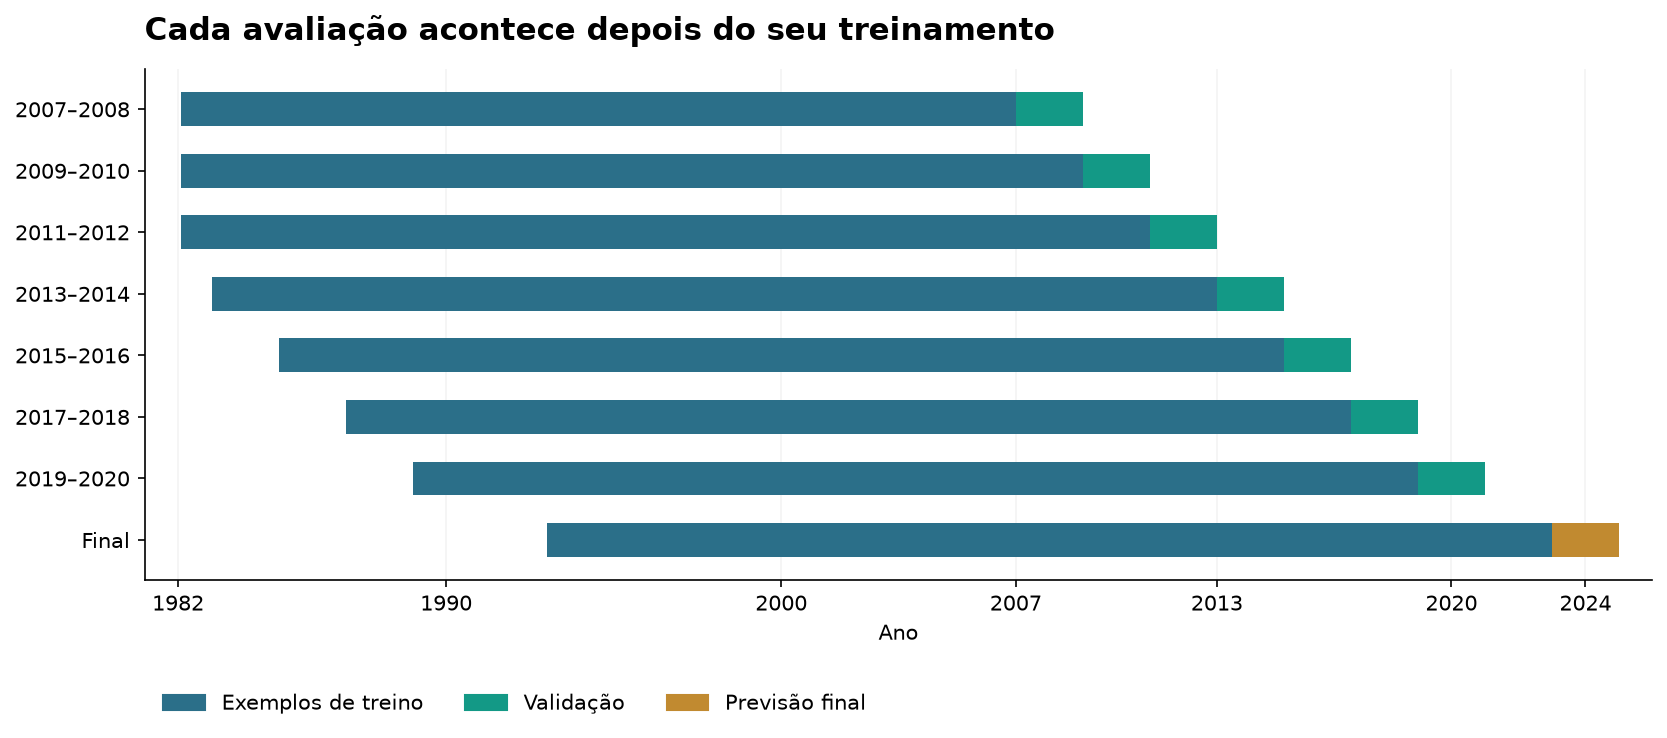

In [ ]:
from matplotlib.patches import Patch
plano_banca=pd.DataFrame([
('2007–2008','1982-02','2006-12',299,'2007-01','2008-12'),
('2009–2010','1982-02','2008-12',323,'2009-01','2010-12'),
('2011–2012','1982-02','2010-12',347,'2011-01','2012-12'),
('2013–2014','1983-01','2012-12',360,'2013-01','2014-12'),
('2015–2016','1985-01','2014-12',360,'2015-01','2016-12'),
('2017–2018','1987-01','2016-12',360,'2017-01','2018-12'),
('2019–2020','1989-01','2018-12',360,'2019-01','2020-12')],
columns=['Bloco previsto','Início treino','Fim treino','Meses','Início validação','Fim validação'])
display(plano_banca)
with plt.rc_context({'font.family':'DejaVu Sans','axes.spines.top':False,'axes.spines.right':False}):
    fig,ax=plt.subplots(figsize=(11,4.8),constrained_layout=True)
    for i,row in plano_banca.iterrows():
        a=pd.Timestamp(row['Início treino']);b=pd.Timestamp(row['Fim treino'])
        start=a.year+(a.month-1)/12;end=b.year+b.month/12
        ax.barh(i,end-start,left=start,height=.55,color='#2b6f89')
        ax.barh(i,2,left=pd.Timestamp(row['Início validação']).year,height=.55,color='#139986')
    ax.barh(7,30,left=1993,height=.55,color='#2b6f89');ax.barh(7,2,left=2023,height=.55,color='#c18a30')
    ax.set(yticks=range(8),yticklabels=list(plano_banca['Bloco previsto'])+['Final'],xlim=(1981,2026),
           xticks=[1982,1990,2000,2007,2013,2020,2024],xlabel='Ano')
    ax.invert_yaxis();ax.grid(axis='x',alpha=.15);ax.set_axisbelow(True)
    ax.set_title('Cada avaliação acontece depois do seu treinamento',loc='left',fontsize=15,fontweight='bold',pad=14)
    ax.legend(handles=[Patch(color='#2b6f89',label='Exemplos de treino'),Patch(color='#139986',label='Validação'),
        Patch(color='#c18a30',label='Previsão final')],loc='lower left',bbox_to_anchor=(0,-.3),ncol=3,frameon=False)
    PASTA_FIGURAS_REFERENCIA.mkdir(parents=True,exist_ok=True)
    fig.savefig(PASTA_FIGURAS_REFERENCIA/'calendario.png',dpi=160,bbox_inches='tight');display(fig);plt.close(fig)

## 8. Métricas e resultados auditados

$$\mathrm{RMSE}=\sqrt{\frac{\sum_i(\hat P_i-P_i)^2}{N}},\qquad
\mathrm{MAE}=\frac{\sum_i|\hat P_i-P_i|}{N},\qquad
\mathrm{viés}=\frac{\sum_i(\hat P_i-P_i)}{N}.$$

O RMSE penaliza mais fortemente erros grandes; o MAE representa o erro absoluto médio; o viés indica tendência à superestimação ou subestimação. O total de avaliação é **13.198.248 pares mês-pixel**. Todos os pontos entram com peso igual. Para agregar períodos, somam-se os erros quadráticos antes de extrair a raiz: não se faz a média dos RMSEs.

As tabelas descrevem os componentes da arquitetura e sua combinação. Foram calculadas com dados reais e são exibidas sem novo treinamento. Ativar a reexecução da validação recalcula as métricas e exige concordância com o registro.

modelo,rmse,mae,vies,n
Árvores + SEAS5,1.756147,1.052139,0.021323,13198248
Árvores + SEAS5/CFSv2,1.754163,1.049707,0.016004,13198248
Média das árvores,1.753321,1.049601,0.018663,13198248
Regressão local,1.759038,1.048685,-0.010590,13198248
Solução híbrida,1.748951,1.045834,0.011350,13198248


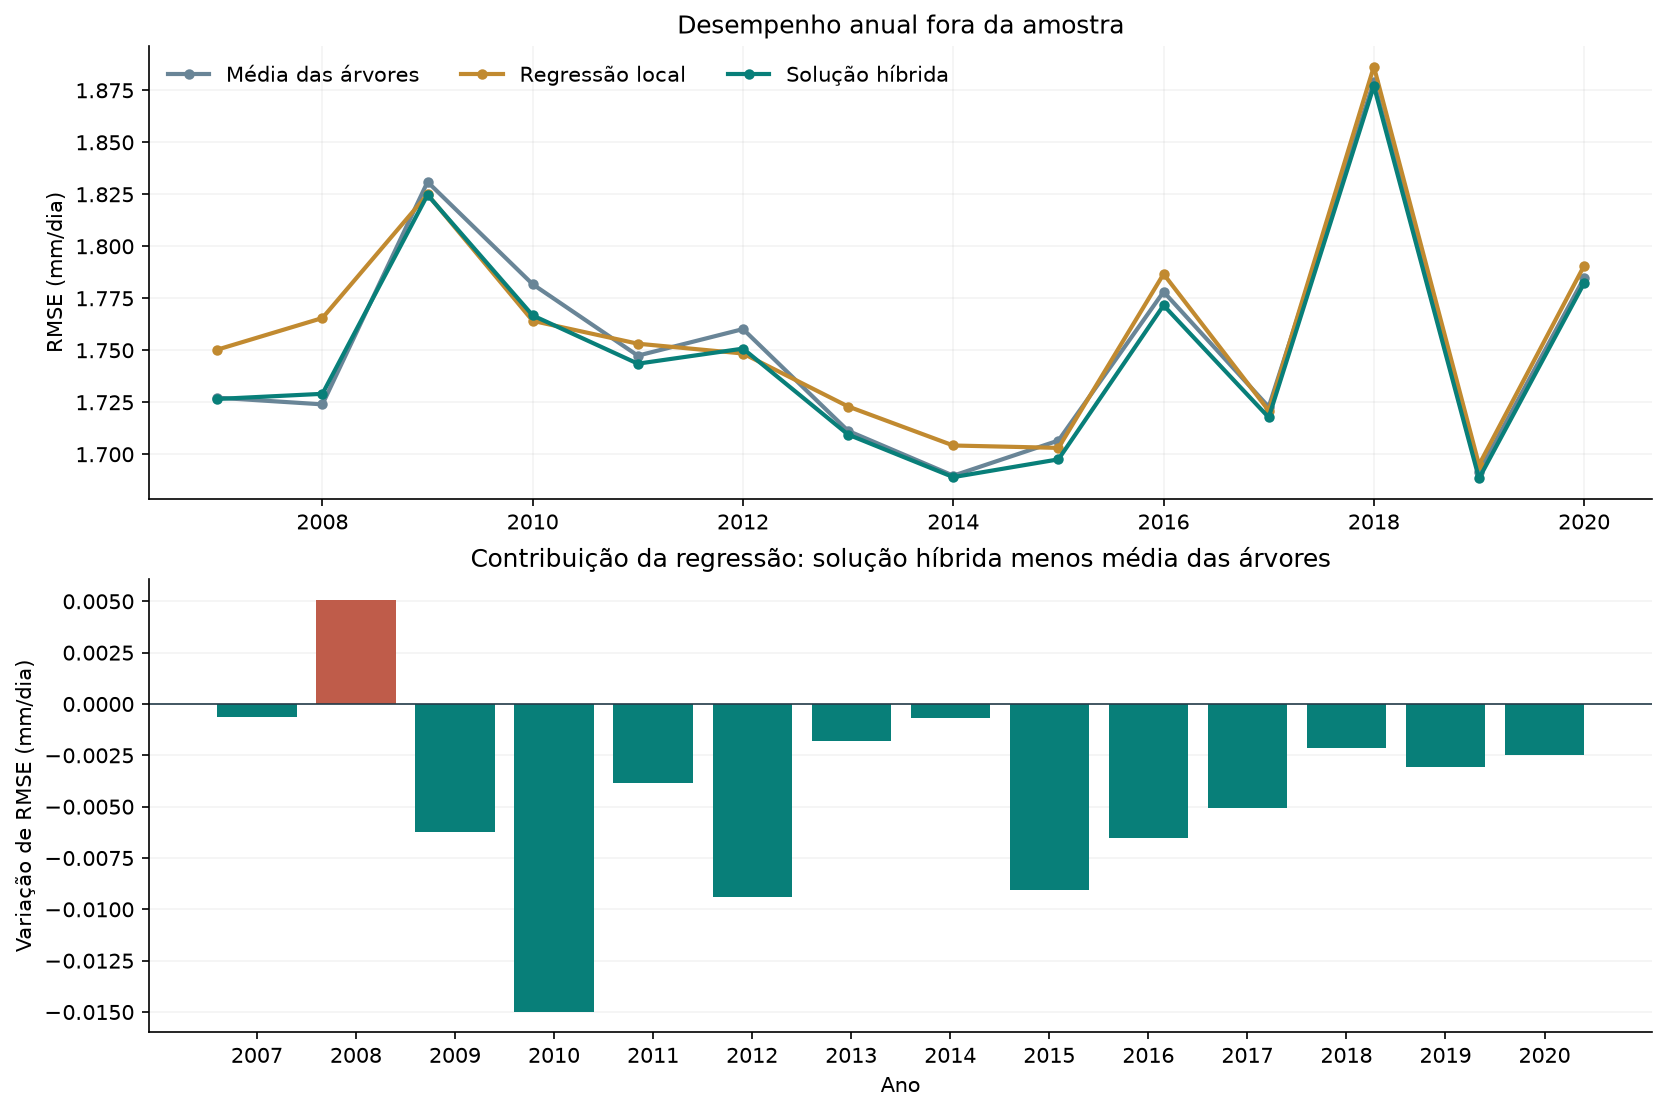

ano,rmse,mae,vies
2007,1.726587,1.025113,0.025145
2008,1.729059,1.036373,-0.076289
2009,1.824718,1.097275,-0.082454
2010,1.766755,1.075141,0.049492
2011,1.743557,1.039284,-0.083587
2012,1.750799,1.076431,0.026171
2013,1.709454,1.027391,0.046093
2014,1.689001,0.985320,-0.021499
2015,1.697553,1.022955,-0.029889
2016,1.771616,1.068648,0.065912


In [ ]:
ROTULOS={'arvores_seas5':'Árvores + SEAS5','arvores_multissistema':'Árvores + SEAS5/CFSv2',
         'ensemble_arvores':'Média das árvores','ridge_local':'Regressão local','solucao_hibrida':'Solução híbrida'}
historico_global=pd.DataFrame(BANCA_REF['global_']).set_index('modelo').loc[list(ROTULOS)].reset_index()
tabela=historico_global[['modelo','rmse','mae','vies','n']].copy();tabela.modelo=tabela.modelo.map(ROTULOS)
display(tabela.round(9))
anos=pd.DataFrame(BANCA_REF['anos']).pivot(index='ano',columns='modelo',values='rmse')
with plt.rc_context({'font.family':'DejaVu Sans','axes.spines.top':False,'axes.spines.right':False}):
    fig,axes=plt.subplots(2,1,figsize=(11,7.3),constrained_layout=True)
    for modelo,cor in [('ensemble_arvores','#698597'),('ridge_local','#c18a30'),('solucao_hibrida','#087f79')]:
        axes[0].plot(anos.index,anos[modelo],marker='o',markersize=4,label=ROTULOS[modelo],color=cor,linewidth=2)
    axes[0].set(ylabel='RMSE (mm/dia)',title='Desempenho anual fora da amostra');axes[0].legend(ncol=3,frameon=False);axes[0].grid(alpha=.15)
    delta=anos.solucao_hibrida-anos.ensemble_arvores
    axes[1].bar(delta.index,delta.values,color=['#087f79' if v<0 else '#bf5c4a' for v in delta])
    axes[1].axhline(0,color='#243b49',linewidth=.8)
    axes[1].set(ylabel='Variação de RMSE (mm/dia)',xlabel='Ano',xticks=list(anos.index),
        title='Contribuição da regressão: solução híbrida menos média das árvores')
    axes[1].grid(axis='y',alpha=.15);axes[1].set_axisbelow(True)
    fig.savefig(PASTA_FIGURAS_REFERENCIA/'resultados.png',dpi=160,bbox_inches='tight');display(fig);plt.close(fig)
anual=pd.DataFrame(BANCA_REF['anos']);anual=anual[anual.modelo=='solucao_hibrida']
display(anual[['ano','rmse','mae','vies']].round(9).reset_index(drop=True))

### Interpretação

A solução híbrida apresenta RMSE **1,748951169**, MAE **1,045834189** e viés **+0,011350132 mm/dia**. Sua contribuição em relação à média das árvores aparece em seis dos sete blocos e em 13 dos 14 anos; o bloco 2007–2008 merece atenção por não melhorar no agregado. A comparação avalia o efeito de combinar componentes e não demonstra superioridade em todo regime climático.

O resultado público informado é **1,65354**. Esse número se refere ao subconjunto público de 2023 e não é diretamente comparável ao RMSE agregado de 2007–2020, pois os períodos são diferentes.

## 9. Limitações e cuidados de interpretação

- **Validação de desenvolvimento:** os blocos históricos foram consultados no desenvolvimento e na definição de parâmetros. Não constituem uma avaliação independente após toda a seleção. O período 2021–2022 também já foi consultado no desenvolvimento; aqui ele serve somente ao ajuste final.
- **Dependência entre observações:** os pixels e os meses apresentam dependência espacial e temporal. Milhões de registros não equivalem a milhões de amostras independentes.
- **Previsões retrospectivas:** os hindcasts são produzidos retrospectivamente. Conferir inicializações anteriores ao alvo não prova disponibilidade operacional da mesma versão e do mesmo produto em todas as datas históricas.
- **Cobertura e resolução:** interpolação não recupera processos menores que a resolução das fontes; topografia e extremos locais podem continuar mal representados.
- **Estacionariedade:** referências de 30 anos e coeficientes fixos pressupõem relações suficientemente estáveis; mudanças de regime podem reduzir o desempenho.
- **Métrica global:** um ganho médio pode coexistir com perdas em regiões ou episódios. As tabelas anuais ajudam a identificar essa heterogeneidade, mas não substituem uma avaliação regional dedicada.

## 10. Implementação reproduzível

As próximas células implementam as operações descritas. Os nomes dos componentes são descritivos e os parâmetros permanecem congelados. O modo padrão ajusta **dois LightGBM e uma regressão ridge por ponto** para o período final. A validação opcional acrescenta sete pares de LightGBM e sete conjuntos de regressões locais.

O resultado não depende de previsões previamente exportadas: os arquivos intermediários dos componentes são produzidos nesta execução. O código verifica dados de entrada, datas, ordem das features, calendário, não negatividade da saída, IDs, cobertura, escrita e SHA-256 do CSV final. Não realiza submissão automática.

### Biblioteca de funções — Importações, parâmetros e índices oceânicos incorporados

In [ ]:
from pathlib import Path
from datetime import datetime, timezone
from time import perf_counter
from itertools import zip_longest
import gc
import base64
import gzip
import io
import hashlib
import importlib.metadata
import json
import platform
import numpy as np
import pandas as pd
import xarray as xr
import lightgbm as lgb
import matplotlib.pyplot as plt
from IPython.display import display, FileLink
PASTA_DADOS_MANUAL = BANCA_PASTA_DADOS
PONTOS_POR_MES = 5000
ANOS_TREINO = 30
ARVORES = 300
SEMENTE = 42
PESO_base_atmosferica = 0.875
PESOS = (np.arange(61, dtype=np.float64) / 40.0).tolist()
CORTE_FINAL = '2022-12-01'
FIM_DESENVOLVIMENTO = '2020-12-01'
TOL_AUDITORIA = 1e-06
TOL_COMPARACAO = 1e-08
PARAMETROS = {'objective': 'regression', 'metric': 'rmse', 'learning_rate': 0.05, 'num_leaves': 31, 'min_data_in_leaf': 150, 'lambda_l2': 10.0, 'feature_fraction': 0.9, 'bagging_fraction': 0.8, 'bagging_freq': 1, 'num_threads': 4, 'seed': SEMENTE, 'deterministic': True, 'force_col_wise': True, 'verbosity': -1}
BLOCOS = [{'nome': 'H1', 'corte': '2006-12-01', 'inicio': '2007-01-01'}, {'nome': 'H2', 'corte': '2008-12-01', 'inicio': '2009-01-01'}, {'nome': 'H3', 'corte': '2010-12-01', 'inicio': '2011-01-01'}, {'nome': 'H4', 'corte': '2012-12-01', 'inicio': '2013-01-01'}, {'nome': 'A', 'corte': '2014-12-01', 'inicio': '2015-01-01'}, {'nome': 'B', 'corte': '2016-12-01', 'inicio': '2017-01-01'}, {'nome': 'C', 'corte': '2018-12-01', 'inicio': '2019-01-01'}]
VARIAVEIS = ['cloud_cover', 'geopotential_850', 'rel_hum_850', 'shum_850', 'surface_pressure', 't2', 'temperature_850', 'u_850', 'v_850']
FEATURES_base_atmosferica = VARIAVEIS + [v + '_anomalia' for v in VARIAVEIS] + ['latitude', 'longitude', 'mes_alvo_sin', 'mes_alvo_cos', 'clima_tp_alvo']
INDICES_NOMES = ['nino34', 'nino12', 'tna', 'tsa']
FEATURES_OCEANO = [n + '_lag1_anomalia_fold' for n in INDICES_NOMES]
FEATURES = FEATURES_base_atmosferica + FEATURES_OCEANO
ORDEM_BLOCOS = [b['nome'] for b in BLOCOS]
REF_base_atmosferica_GLOBAL = {'rmse': 1.8101121800554918, 'mae': 1.085263304, 'vies': 0.022914405, 'peso': 0.875, 'n': 13198248}
REF_CLIMA_GLOBAL = 1.8496420039184214
COL_REF = ['rmse_climatologia', 'mae_climatologia', 'vies_climatologia', 'rmse_base_atmosferica', 'mae_base_atmosferica', 'vies_base_atmosferica']
REF_FOLD = pd.DataFrame([['H1', 1.839845926, 1.075422198, -0.089676034, 1.780676831, 1.052738061, -0.065322037], ['H2', 1.985533781, 1.17764983, -0.08012667, 1.89938271, 1.144985077, -0.005764244], ['H3', 1.833986724, 1.103440925, -0.076567408, 1.796554028, 1.089670267, -0.03648091], ['H4', 1.721495863, 1.024299361, 0.024806943, 1.707686158, 1.020427292, 0.025005878], ['A', 1.854691975, 1.125081751, 0.131241513, 1.816861444, 1.110338007, 0.142916522], ['B', 1.853953344, 1.097407801, -0.078870291, 1.84693707, 1.094939451, -0.043868717], ['C', 1.848450902, 1.09751788, 0.138663834, 1.816897806, 1.083744973, 0.143914343]], columns=['bloco'] + COL_REF)
REF_ANO = pd.DataFrame([[2007, 1.842494728, 1.077941774, 0.00183693, 1.790923888, 1.057678144, -0.009944569], [2008, 1.837193305, 1.072902621, -0.181188997, 1.770370463, 1.047797978, -0.120699505], [2009, 2.022061463, 1.192506261, -0.074923059, 1.942703508, 1.164179748, -0.024245971], [2010, 1.948321388, 1.162793399, -0.085330281, 1.855050521, 1.125790405, 0.012717483], [2011, 1.852994051, 1.084233803, -0.212546637, 1.794078445, 1.068334992, -0.127252253], [2012, 1.814780332, 1.122648046, 0.05941182, 1.799026204, 1.111005543, 0.054290434], [2013, 1.721092997, 1.034856288, 0.020723158, 1.702893681, 1.03280552, 0.033810877], [2014, 1.721898635, 1.013742434, 0.028890727, 1.712465223, 1.008049065, 0.016200879], [2015, 1.846480311, 1.121117686, 0.129572222, 1.79034488, 1.094301357, 0.125278846], [2016, 1.862867443, 1.129045816, 0.132910804, 1.842996535, 1.126374657, 0.160554197], [2017, 1.785312205, 1.081442101, -0.139569874, 1.756382116, 1.070597014, -0.078965828], [2018, 1.92014227, 1.1133735, -0.018170709, 1.933255012, 1.119281888, -0.008771606], [2019, 1.808213478, 1.059386025, 0.158010997, 1.770023859, 1.042689764, 0.154691493], [2020, 1.887830897, 1.135649734, 0.119316671, 1.862592499, 1.124800182, 0.133137192]], columns=['ano'] + COL_REF)
FONTE_CODIGO_ETAPA2_SHA256 = '7695f2302636e4d3089062a76523e91ec0d64a66b320b35a443940cd1b691c9a'
FONTES_INDICES = {'fonte': 'NOAA Physical Sciences Laboratory', 'captura_utc': '2026-09-21T23:00:40.933121+00:00', 'unidade': 'degC', 'tipo': 'indices mensais de anomalia de temperatura da superficie do mar', 'interpretacao_temporal': 'Versoes retrospectivas, com mes de observacao estritamente T-1; uso de dados externos confirmado pelo participante. Nao e arquivo de vintages em tempo real.', 'inicio': '1976-12-01', 'fim': '2024-11-01', 'meses': 576, 'colunas': ['time_origem', 'nino34', 'nino12', 'tna', 'tsa'], 'fontes': [{'indice': 'nino34', 'url': 'https://psl.noaa.gov/data/timeseries/month/data/nino34.long.anom.data', 'arquivo_bruto': 'nino34.data', 'sha256_bruto': '46e501b91f624ef85b525d73fbb427f9d04d30411ba6e5c7cff579b35fb4ff01', 'inicio_declarado': 1870, 'fim_declarado': 2026, 'rodape': '-99.99\n  NINA34\n 5N-5S 170W-120W \n HadISST \n  Anomaly from 1981-2010\n https://psl.noaa.gov/data/timeseries/month/\n  units=degC'}, {'indice': 'nino12', 'url': 'https://psl.noaa.gov/data/timeseries/month/data/nino12.long.anom.data', 'arquivo_bruto': 'nino12.data', 'sha256_bruto': 'b13ad5ad085cd13e70ec5d82662b509d522204e38a8eefd133f14be270e51928', 'inicio_declarado': 1870, 'fim_declarado': 2026, 'rodape': '-99.99\n  NINA12\n 0N-10S 270W-280E \n HadISST \n  Anomaly from 1981-2010\n https://psl.noaa.gov/data/timeseries/month/\n  units=degC'}, {'indice': 'tna', 'url': 'https://psl.noaa.gov/data/correlation/tna.data', 'arquivo_bruto': 'tna.data', 'sha256_bruto': '387c4125f377e57bcb683a849aefcd76da7d7f3cdcb2ac68ab086ceadf300e8b', 'inicio_declarado': 1948, 'fim_declarado': 2026, 'rodape': '-99.99\n  TNAa\n Tropical Northern Atlantic Index\n SST Anom 5.5N-23.5N; 15W-57.5W\n  Using HadISST1.1: Climo 1991-2020\n  NOAA/PSL\n  https://psl.noaa.gov/data/timeseries/month/'}, {'indice': 'tsa', 'url': 'https://psl.noaa.gov/data/correlation/tsa.data', 'arquivo_bruto': 'tsa.data', 'sha256_bruto': '700c0dffda0f19c1254ba482808b345eaa0538f5bf09fc3bc025f46a5fbe3a69', 'inicio_declarado': 1948, 'fim_declarado': 2026, 'rodape': '-99.99\n  TSAa\n  NOAA/PSL\n  https://psl.noaa.gov/data/timeseries/month/'}], 'sha256_csv': 'b6f444fbec48681c1e5b46a5c22aa197ad91c7fbbdaff82c3ed3a9c63f7c15a4', 'transformacao_no_modelo': 'Recentragem mensal em cada fold, usando somente as 360 origens de treino; sem padronizacao, medias moveis ou indices adicionais.'}
INDICES_CSV_SHA256 = 'b6f444fbec48681c1e5b46a5c22aa197ad91c7fbbdaff82c3ed3a9c63f7c15a4'
INDICES_CSV_GZIP_BASE64 = 'H4sIAAAAAAACCm1cy44tuY3cz7ecGuj9+JqBF4bRC7eBmf5/zElGBMkse1N90YpSSqL4CJKqv/7459//51//+8c//v7Pz59//PmvPuw/tX3++vNvn7/+72//Ve9eP7X9lPop/73G90ebn5/vP8vzc+wHsL+jABwDXBsywOwEcIZpv1xHIJqm6EDg//aDMfv3IGI8iB9fwYl/O2QSUrp9wQabAfslZOE7fX1/FMyBvVQCNhcyPz5Pw3oJOADg09PGlv2s+sblFLbPadMvW1dtQNTCA7v4PUMsWyeXUe1IK1eAM507nxik8kVgzH4bX8RxHBfLttUV++3asWoiJBdbXbctN0xHAMVSbPq9n3/a904hQFLpmz+/37AdX00hoeAg5ohl3EvIIgQSOzgJ+84+hGxBTlwe3MLeCTmEQBprxKkOrfYKgt/EinCAhEA0dor2m50nYzIkpBJS7cBGTOUInmt5jqP1tG5b63XRlOkAXMZxCdAMWNzxY52VAEoGJ4nLyL1NIgYRGxKW4vXCcdeW+zFlsw35DbuuK+VR6/0oTIXCaAmSyVeDpDDpmt9QFbtjhQt9joXjUpTz3ONGnX/WiXGpSW+P9cEFg6ZxgspjtJtbW2izVuCm64ZIqVLPxTrFJUHTVPwUhgCcondfPwRmwn4A3UVl6iMd8nHKASsrxa3caARMFyU/MGkFOS6btXWWWIDZtGecJgufhQ3AbepaglSDdxEQaOIiRKqBY6z49wYQEFcNDML00VRPQniauKu00XHzH0RzA/xTeXt7hdo/iEqJPL9ikHbdEONEK0US9qLH5d+dkK7LTdP8EdqMzoOQ5cIme/X7fTTHfO23PaKtMISTiBWW4EdWEj+nJnHD1cNO44xxw2pIB5/HTWyQ0SZE0oEVx2DrZkGAcOGUnoRzP9SFB6FzhV/lhT/mB4kIsxXCb3FLWsiGl6fFhs2sPBAJpybTiQVbvPBA3sKBf2rdHc8DkdLAh9bQ/SUEtWbN8OQG3pUAqs1tH+0Zerc1w05xzUreaWsrtF+3u5+FV9nayIUP/p5zk/WFw+EnIJX2aH2jIuztTusBVAL2p3MXAPgMDYCv+ek0IfuGQnWKpD33q32vfwQbpRLAGb73t/F2mDpUjXdsYj2b6BbCnbienaKoj7A74iaGI4vj08cHFR9fsRjhAVAQ6wHM5eZha4Idetafw/4xx5g/ceJOdapjT2a8h4LMgtMMXeM2qSAWUsnbzGQluxSkwhDjt9tyd/IgdLevuQHdfgFG6McpEbf1Yi6KCE0xe7oNjxbC3I/QDoYM1f3OGESMVxijIPjDEPRByHQ997XqxGCe9BnZrotwjT5L7vdBuOlKurHMSekz541QMPzEqkRILrADWIIhFudww3XS3TWd7YsIl8sJK2mxaO1ENCJwqDOpCbRgJsncOHc4qNIIcenW8E3TJD2JkGjuisgRUzV9R7K555kE7vHUMKIzhPOcfKWALyCFEAlnwwfOEIBFZw9E0lm41YMmMu3HpXMN0YLM+HdcbXaIQCE6IC4fmL7TCJfrmeFY4OJuuJ7CHbve0ABrO4+leBArxAOp4WRBBHAdV4gHC8GFOsUiKyIkHviLM3iCCmFWSGfU+MChzSJE0hk79rtHqM4K6cBgQ4GM/FathK6lriC8izECEccdnFzttgOpHGdsjJOgLzUsJ1BwfItH9qvnVTqFDJN+qYoE0N3fx/pAcy796AMQr69wF7jmk1E4AeSg3/XrfkEssEPbfct3l5V0CSdyOD6cCFdylCC5Z7uTv+Zlp4/jFEXnOb9ZYjDQyuFN/zy0C4TPk8MHw+PgE4zxfPv07vNxGL0quq9cGwRQH5tWH5OjYW5dx2/xqwnJyN7gt52+T2xf8aXdwuDu6zoJNH6BKCuYO8Or7TQMpCCYO311A0FS2JCI+7i8w9r9IWDKX077iUDRTpiARQDi9EvHLl7jnL2aQak0KyUU1il7NUZSedftpH2fl4jH3VfR8eZ64IS92SlVOmzzUnUSUYmA51jJmBZB5ECgAHeHO0MILsr+QFJaaW0Pn8XZn7XCOkY4CPMj0s7dOH0xm12IGPJ12XKPcFOJtx9zHzAxsGQwHjcMFMNVpbHSd/bLyg0x44SQ90CQNJZuMC74Ta79xERwQAsIdx3jdzTkCJn9nvJ+ogyEvPkEbgADvGe7Nzg8LVCPn+sQkVinq8tx73KDxSsbGLkEcww38fgV89t9L5pierrC+UzZnn+6weRLiRiXi9FH5DhwNTaJ5w/V7hZ3HDCEK7GxrjnoOpgQOX4yrQEg14ET3Yk+V04hHl+Ox0CYovDIncannAPZoJ1GjcSKckye07NQ6dYQCkOSuCNmH26NJFfxQ+v7NcXwDJOHc7IzRMycjPUEoQRfg51Mp5vLY8tbgyU2Z4lrvxZJgYzui0QG0rKst7o8UgIBpmVyF+7KbZoW7GBeAuSIx0c6PVb+hLyJLRJmZUT2/DZ35StpwfCcym3uyjHDiLDFEhm3uSs3T8cYD9ZFnyBPHM+Pne7FOQSQKLYnWjhdF6LyUgVjn89JbucsFf78BmOHzlB/riePbktMMeUd5npBPNOV8vMwckb8b0tJ4BkkEHRMu40k8EhFCYTym5Dm+VNPcpEi2Zl21xHoaOIuEHx3FTHbTdMUub/bo26yPYajOR4EjJQFwaG35rz49gixnignZ5MtyLuJvj+X7yQK1vWJ7RnSt0Fo+sTxaFiqijtqPvz20JDlZsuumUUBt0ciePkXLI9gCaXb3VzBpDM9O0VDb3dRoNSCK7OLYr07woWMsNrKKxLhfijZ/518SGLuJSU393LCdYeLo1g403L1qBOhbPCIiH2X8BHDBcI83g2TZNWDO37RD1CYtcNgDBcJ7iMYDOgD/MyI5HzyVVhp515eDIRRVRT17nibrZlS8JVnKrNlUTms94ig685gIOXj7KV80jjlerYbb7OyuJoz1CMX0KrC5DvDgWzkhulNmeK408UBgYU3avrCennK/mFeFs54RnI+ygegEpr/vKIoC9QbrQ4Rb46ebEXlHG6uaHVrZGUbD8rNFW6sKRrDG37G4yxMYsSDZMwQiaOv6bkiHKxF2jdT9OXBYPNg/a7fuS2rj9kPS6DdRNC7MQLbrPFGSDTT88LMCu2KEZubyPljRypV2ajh1CL2y3Qj5LePWBH4riSUEr7WjI/v9L7KhDMZ1sJJXCqwSsgy8P4XQt7hL3IfgBcuNlInnclLd264YjsVTLpbRhYhJhGapEWcD9uwChHJdMliIJY5jQhqiiUhLGUAQ30qx6erYqOlRxb4cpxU/bv2jpokzPA9HCdX/4ZYHfwtFVJukPU7niTxiQpF0wcu8txf9Ry0V9XZyN2ei/9+doCG1vAh2zPxw9LYTSVRHZDn4Z/ZVSxlDvueyMI/SfIJmqSc7j2eg/9aifb4UDOH+vbx2Grc1zDu/Akf/hwNCoiwMxxWJeQ8w7BuItk3VddRpSgKJywNdFNpfXuew3IWiEFSXf08H71Dnn5ofqmCEdkelUwejSfeUXVoXmCCopzI7+LCtCpY5f4jvSu11eWEOiZyTkXMpadCiCYZ1dk5i5eNCM/u2kYSIy1CyDqdbEuPLzWT853Yqm38ELGihvDzrjsLIYGclDc0RBfipCQzi/tMBxFwX1PcLQDczn1VQyJIOcrq3htSGSkfUc8nDj3EYraa1c+GNGgrpYRYYNmQemcGuhHyTt2P8HGOUNIEYTiCeRTbJxEjMiKy1mZhvqoPwPwPZRmRCEI84z7j0OFjvtEKIPvliNWOQ4MOiDuOVCBA0FkEuaGO7hAA/4aABnHPgcsx/sOxhT+fESDitmm5Uaxqv+f6RgVfSCq1I6zHLei0rYS4S09pFTF2QpJTl9bJmRAxws/5TlBpJmC+HOEarufYcC6115zvQvoFCEVa1aP70uJAUp0d5gfdTOW1zptcdkVCFVG8PhJOHSH+cD9VOhH15fZhL1ntJqK9GhzM1DGtYZcxldkZoQwnd9+QD4iWM0msMDIoAECpE89dtCSSKLDX4b0tYHW4p1Ffb9EYMdAdw/HlXucn9e1pm0HWZ8owmuNoApCDkN3ky6ddkoMgRZpodOMulYM3T44P0bdwBlEQM/qw10hF6ahFQUa0CcG2nGc8KPo9nodqvocg6IuE101PLwR073Fy9avgqgSMV+PGLR6N4t721EFnEW2f4QS1CleOG6SROT9NsjOttIYyuKXB8ZM60izPbxzBt3FzXhLhx0GIYuPigjC+FtKjqM3Pe6fWVXiBU1ocbqnTqzMPq68HO2/Lw1c1kmG85ZwofnWEdU/MvBYvpIH+YAWJmC+mJ7w9UN+YubXprtRnKsTKR7xuZKQvAeotDQulkjYBFMJSN6c3ZXKcUljbQwKqJ8Ylhd2l+eR4Gq8pl2miUL4ewzzGXRX9sjr5DM/I6K6PhND8IgcXZwXGhQhVCS4O22o3fDJOxPjISRxjWyyZagLl171WdcgEOb48zyoVYtJDG5ADT1RnvhHn1d8Ed1XDJCU2DsK/UhGuAxFtcpPlM0/FcyNRMB8RkF5SbSBacu8qXS6ynS8ikXGEgKDrasQCwufw5Jz2RkCPwF+tlyXuw3q57R9VKVc4ifW7RQ7anaKQFfmR641HiO40Q+RHFIBGaBdl8u5NrHTKHL7pQu8T/APDrg9PiRZmARECh7Ntv5Hs0trkG0zRUDQ4vrZoezeuNne42Mvx5nUYXrZ+wgUnzl2nJyzVjEjESDlHXiVvDARipmiyIg2cY6+dfIPNwXReBNg71AJByB0pGBDkpNC3MlztKTLaUaktdqn7iHZeTuKcA4yCvObGbdlBOuaJUis9+iFEhAF9L6uH48WWz7/RjhKWH+7uBO1A8FGX16YhvRO0A46qS5AIHFIB3dRiFrcoiMDOuwdLlnZ/5C9y2/vw3Pf8yF0kYm4JSROtrQX27ryMlYpWzX3ueUWzSsaF8uRW9xKMqfoFT43uKrr5x3yK9moi443oHiYmZl5KpGzq9vDmvuxU1Emmx2CJmCM1ecRkjNwDkR6HKCge0EgCZmqGr9uDmDE4vjxR7A1Q153bjSrg/chzb4+eotMdRcIlSRcNX4+VPUvY07hn0pc71fKRR7kRxF4F7JAj9yYzdXwD6BZ8frsWz6Hbfs2t2uGOxWEZuaNW/wuvx2GmpqiE40PCMgfHRwoKpiXzJ5pEMDzzW4l+1QbUNL5+XjVZ5fJ9+p3a9mgBN+IiAs6rQcRy7+pRBEB2aUY7ed+6XbWEWVqTeQhGXY1HEEYJxu96HNsIcJOkHK3U0RZZk0EqHjQgRmsEtMhxKHy2A9N4f3n74RFwPwRIAdipNv2GCjCj71TPGIrb75oINuZdHtfYNaupk93OOFKgRWs8r+R/Kw4oBNxXU6OHYrS5NbFrNAHv+opIag1RlH+z7KYstYYwSnonxvdLttVEr2+PRAz7uxchLborPSzQiyQgfpUyUukFmteSVbrOANmXopXMaP2P/A0ffwCxEk+/15OnUKBg2eZDTrw+wfVvmVJIaKwycPym3zf178NzUbW5adKTk09q8QOg5vcx1iY09LIEgHcDz0pEzqboqYDRghh5FFh7evBRcl1JAUrtKZYanohAxss/MlLgXsk03UjXRLNBUOxAhju7mlg2e9FGZLKF2K8p+npnh2rqZGcN2g2+b/XGqywlqRhRc6uRguIxB+IQUV/vK2akwoxf1NTIrmTI66nHFzJeQlEEQBrTiXg/w2FXzHTeXXNFfEdfLmKlqlletK/NV6c6EDM9ydwjPxPD+ErPyFQTcuubquH9o146JvUuASfpWOLWvoubSAhSM13+twbrRvpzRM6QJykNOc4TCjtPOC7avbUGVSee8Zl5RoSqzqFqMG9w2ZWeJUwCXkmo/AoIe5i5xOQdRnEE03t3LADwnuT0+2rEfQpcNfo4jafU6dW9rxNuSh+3MCPTy3tWPizHGWPXB1jdQ5Xt/DJDM6p7VqQ7YouQwfTq3tzAqJSh32Z9zpaHvJhHh3V5dW8+PPI0j7A2h/nble9xPeLmcPfKZlXzgIhEXd43BXbnqTHc/vW+/fYDkVrl8PK8ldp8I/5Kte4241aUDDg5eY8S3RSLqanQbZa9TXGEyu9H78GM2J9d1ADUVwGheEUftzdVuKe7e4swEIGm8nb30mM6v1TcVhtTajIHoIexq6ofJQ2N2rZZYouge4Ql+1fiaSq3CYO8c95JycepvFaNF+VwWGOJi2H/+/fzv728lUqf9waQ9e6J0AKiXtTctUEQnMFlcIZ7rtY8dtshgzNZ0PMbY1OcVCrSixTlAAVor2zS6Km5dROSE05VtDO5rvyefEWdVbSSkPl6qTpWvIQq+tDKHbCoKe7mBvH8biQ8oQCNgEiHe0spwo5KwE13Qp2vadyf+A/PJJtJ6RrX64wSz5Pz/P4447EFyGOo6v4dv7m91n3Wdq2JB+RipJ5G0DhdwklXjylTAobnmr0+uZXxr8GoVzzTLJ7xr8Go14pq33Lmd38lwxEqXbcbQam9ZU/jjePXC1w/YtbFDVdwakSB20vkMBvxdhyvbpqzpsP11dffRqjRGXYeCbToOl8jWk1MYpPj7eV0u/Tecs0tOs57JPunH2ALZj2uVA3BtYbfamAmEfN3ApzQ1Uh3bGlsK6/80g8dlxk2B5xXXJ5Yp47gvijfmU75OEPu/fghf4GP4SEEoVPXhNTRbHPLZewwj8ySPjajJXZdorbF6KYR4XMMf2hFQtOJeKeYmM6rXkFriWLjRuG9y1KM0RLFHjJyWedaotgl/vqIOeOpnaS/qOBcxjzi0Tfe7YJ1e7lta6/39fc22k0NcgYIj31oOXW9OEN9dwWg8lkV0LRMsbenVHASdi8SwcajMQsq0T43CHB6fbyMbtzSslItsWs0sCDixJ/TaESM1ytKxvVVRr619IKpEaHwuhKwXss8Hnp07WMnz6sXi56ZbKndHPVA+2W0LQjgWfH4CypMvgAQKY8bT4dOWkN0eizvTbIrgaub+DV6IpB48tpsS/R6H/8zL4iwLgHt9ZdTqqcCLEnQMrvuclnDi8et59f6DXRzNYUfLVrMx8Yzc7aSDf22HurPJ3S/H6bcLX5q3alDe152fwNgXhdf20nMYk48RNTxdX/Et57Jiz8TNC/QujcQzOez1j50blq5P89n5yGLTLtzODKvFN2xP2Vikw/PvG42QXNj93JYrQf2evLo6QQOdThtqCotWJ90pdyDOF9ljfgO0+LKlmizbFJl0bRxfOU/ZIS/wXKVem1Bm/nswFOz/v2TX12hAhdnl55+1+pmeXlPQRu/Exnmm5a3RrSR8hjR8rBoA/4ffzwna7xKAAA='
INICIO = perf_counter()
EXECUCAO = datetime.now(timezone.utc).strftime('%Y%m%dT%H%M%S%fZ')
BASE = Path('/kaggle/working') if Path('/kaggle/input').is_dir() else Path.cwd() / 'outputs'
SAIDA = BASE / 'worcap_banca_hibrida' / EXECUCAO
SAIDA.mkdir(parents=True, exist_ok=False)
VERSOES = {v: importlib.metadata.version(v) for v in ['numpy', 'pandas', 'xarray', 'lightgbm']}
print('WorCAP — precipitação mensal: árvores e regressão local; até 30 anos')
print('Python:', platform.python_version(), '| Versões:', VERSOES, '| Saída:', SAIDA)
pd.set_option('display.float_format', lambda x: f'{x:.9f}')

### Biblioteca de funções — Leitura, preparação e exportação dos dados

In [ ]:
def exigir(condicao, mensagem):
    if not bool(condicao):
        raise ValueError(mensagem)

def sha256(arquivo):
    digest = hashlib.sha256()
    with Path(arquivo).open('rb') as stream:
        for bloco in iter(lambda: stream.read(1024 * 1024), b''):
            digest.update(bloco)
    return digest.hexdigest()

def salvar_json(nome, conteudo):
    caminho = SAIDA / nome
    caminho.write_text(json.dumps(conteudo, indent=2, ensure_ascii=False, default=str, allow_nan=False), encoding='utf-8')
    return caminho

def mostrar_tabela(tabela):
    with pd.option_context('display.max_columns', None, 'display.max_rows', 100, 'display.precision', 9):
        display(tabela)

def localizar_dados(pasta_manual=None):
    obrigatorios = ('treino_tp.nc', 'treino_tp_alvo.nc', 'teste_features.nc', 'sample_submission.csv')
    if pasta_manual is not None:
        candidatas = [Path(pasta_manual)]
    elif Path('/kaggle/input').is_dir():
        candidatas = sorted({p.parent for p in Path('/kaggle/input').rglob(obrigatorios[0])})
    else:
        candidatas = [Path.cwd() / 'data' / 'raw', Path.cwd().parent / 'data' / 'raw']
    validas = sorted({p.resolve() for p in candidatas if all(((p / nome).is_file() for nome in obrigatorios))})
    exigir(len(validas) == 1, f'Não foi encontrada uma única pasta com os quatro arquivos oficiais. Anexe a competição em Input > Add Input ou defina PASTA_DADOS_MANUAL. Pastas completas encontradas: {validas}')
    return validas[0]

def auditar_contrato(tp, alvo, teste):
    exigir(set(tp.dims) == {'time', 'lat', 'lon'}, 'Dimensões inesperadas da chuva.')
    exigir(set(alvo.dims) == set(tp.dims), 'Dimensões inesperadas do alvo.')
    tp = tp.transpose('time', 'lat', 'lon')
    alvo = alvo.transpose('time', 'lat', 'lon')
    datas = pd.DatetimeIndex(tp.time.values)
    destinos = pd.DatetimeIndex(teste.time.values)
    exigir(datas.equals(pd.date_range('1940-01-01', '2022-12-01', freq='MS')), 'O calendário de treino diverge de janeiro/1940 a dezembro/2022.')
    exigir(destinos.equals(pd.date_range('2023-01-01', '2024-12-01', freq='MS')), 'O calendário de teste diverge de janeiro/2023 a dezembro/2024.')
    exigir(tp.shape == (996, 301, 261), 'Grade ou quantidade de meses inesperada.')
    exigir(tp.attrs.get('units') == alvo.attrs.get('units') == 'mm/day', 'A unidade deve ser mm/day; não aplicar conversão automática.')
    for coord in ('time', 'lat', 'lon'):
        exigir(np.array_equal(tp[coord].values, alvo[coord].values), f'Coordenada {coord} diferente entre chuva e alvo.')
    for coord in ('lat', 'lon'):
        exigir(np.array_equal(tp[coord].values, teste[coord].values), f'Coordenada {coord} diferente entre treino e teste.')
        exigir(np.all(np.diff(tp[coord].values) == 0.25), f'Ordem/intervalo incorreto de {coord}.')
    origem = pd.DatetimeIndex(teste.time_origem.values).to_period('M')
    exigir(origem.equals(destinos.to_period('M') - 1), 'Origem do teste não é o mês anterior.')
    exigir(np.array_equal(teste.lag_meses.values, np.arange(1, 25)), 'Defasagens inesperadas.')
    tp.load()
    exigir(np.isfinite(tp.values).all() and (tp.values >= 0).all(), 'Chuva de treino não finita ou negativa; investigar antes de continuar.')
    for inicio in range(0, len(datas) - 1, 24):
        fim = min(inicio + 24, len(datas) - 1)
        resposta = alvo.isel(time=slice(inicio, fim)).values
        exigir(np.array_equal(resposta, tp.values[inicio + 1:fim + 1]), 'O alvo não corresponde exatamente à chuva do mês seguinte.')
    exigir(np.isnan(alvo.isel(time=-1).values).all(), 'Último alvo deveria estar vazio.')
    exigir(np.isnan(teste.tp_alvo.values).all(), 'Alvos de teste deveriam estar vazios.')
    ancora = teste.tp_ultima_obs.transpose('time', 'lat', 'lon').values
    exigir(np.all(ancora == tp.isel(time=-1).values[None]), 'A referência de chuva do teste diverge de dezembro/2022.')
    return {'meses_treino': len(datas), 'pares_supervisionados_validos': len(datas) - 1, 'meses_teste': len(destinos), 'pontos_por_mes': tp.sizes['lat'] * tp.sizes['lon'], 'unidade': 'mm/day', 'alvo_ja_deslocado': True, 'chuva_teste_congelada_em': '2022-12', 'contrato_conferido': True}

def estatisticas_climatologia(tp, corte, anos=None):
    """Climatologia mensal: somas em float64 e mapas em float32."""
    corte = pd.Timestamp(corte)
    exigir(corte.month == 12 and corte.day == 1, 'Esta versão usa cortes no primeiro dia de dezembro.')
    datas = pd.DatetimeIndex(tp.time.values)
    exigir(datas.is_unique, 'Calendário de chuva duplicado.')
    inicio = datas.min() if anos is None else pd.Timestamp(corte.year - anos + 1, 1, 1)
    permitir = (datas >= inicio) & (datas <= corte)
    exigir(permitir.any(), 'Histórico de ajuste vazio.')
    calendario_esperado = pd.date_range(inicio, corte, freq='MS')
    exigir(datas[permitir].equals(calendario_esperado), 'A janela da climatologia não contém todos os meses esperados.')
    somas = []
    contagens = []
    mapas = []
    for mes in range(1, 13):
        indices = np.flatnonzero(permitir & (datas.month == mes))
        exigir(len(indices) > 0, f'Sem observações de treino para o mês {mes}.')
        valores = tp.isel(time=indices).transpose('time', 'lat', 'lon').values
        exigir(np.isfinite(valores).all(), 'Climatologia recebeu dados ausentes.')
        soma = valores.sum(axis=0, dtype=np.float64)
        contagem = len(indices)
        somas.append(soma)
        contagens.append(contagem)
        mapas.append((soma / contagem).astype(np.float32))
    clima = xr.DataArray(np.stack(mapas), dims=('month', 'lat', 'lon'), coords={'month': np.arange(1, 13), 'lat': tp.lat, 'lon': tp.lon}, name='climatologia_mm_day', attrs={'units': 'mm/day', 'ajuste_inicio': str(inicio.date()), 'ajuste_fim': str(corte.date()), 'janela_anos': 'todo_historico' if anos is None else anos})
    return (clima, np.stack(somas), np.asarray(contagens, dtype=np.int64))

def ajustar_climatologia(tp, corte, anos=None):
    clima, _, _ = estatisticas_climatologia(tp, corte, anos)
    return clima

def metricas_mensais(observado, previsto, modelo, bloco, corte):
    exigir(pd.DatetimeIndex(observado.time.values).isin(pd.date_range('2007-01-01', '2020-12-01', freq='MS')).all(), 'Métricas fora de 2007–2020 são proibidas nesta execução.')
    observado, previsto = xr.align(observado, previsto, join='exact')
    observado = observado.transpose('time', 'lat', 'lon')
    previsto = previsto.transpose('time', 'lat', 'lon')
    datas = pd.DatetimeIndex(observado.time.values)
    exigir(((datas >= pd.Timestamp('2007-01-01')) & (datas <= pd.Timestamp('2020-12-01'))).all(), 'Esta execução só permite calcular métricas de 2007–2020.')
    reais = observado.values
    previsoes = previsto.values
    registros = []
    for i, data in enumerate(datas):
        real = reais[i]
        pred = previsoes[i]
        exigir(np.isfinite(real).all() and np.isfinite(pred).all(), 'Métrica não pode ocultar NaNs ou infinitos.')
        erro = pred.astype(np.float64) - real.astype(np.float64)
        sse = float(np.square(erro).sum())
        n = int(erro.size)
        registros.append({'modelo': modelo, 'bloco': bloco, 'corte': str(pd.Timestamp(corte).date()), 'mes_alvo': str(data.date()), 'ano': int(data.year), 'ano_no_bloco': int(data.year - pd.Timestamp(corte).year), 'sse': sse, 'n': n, 'soma_erro': float(erro.sum()), 'soma_erro_absoluto': float(np.abs(erro).sum()), 'rmse': float(np.sqrt(sse / n))})
    return pd.DataFrame(registros)

def agregar_metricas(mensais, grupos):
    tabela = mensais.groupby(grupos, as_index=False)[['sse', 'n', 'soma_erro', 'soma_erro_absoluto']].sum()
    tabela['rmse'] = np.sqrt(tabela.sse / tabela.n)
    tabela['vies'] = tabela.soma_erro / tabela.n
    tabela['mae'] = tabela.soma_erro_absoluto / tabela.n
    return tabela

def indices_dos_ids(ids, previsto):
    partes = ids.str.split('_', expand=True)
    exigir(partes.shape[1] == 4, 'ID precisa conter ano, mês, latitude e longitude.')
    padrao = '\\d{4}_(?:0[1-9]|1[0-2])_-?\\d+\\.\\d{2}_-?\\d+\\.\\d{2}'
    exigir(ids.str.fullmatch(padrao).fillna(False).all(), 'ID oficial malformado ou ausente.')
    ano = partes[0].astype(np.int64).to_numpy()
    mes = partes[1].astype(np.int64).to_numpy()
    datas = pd.DatetimeIndex(previsto.time.values)
    chaves_tempo = pd.Index(datas.year * 12 + datas.month - 1)
    ti = chaves_tempo.get_indexer(ano * 12 + mes - 1)
    yi = pd.Index(previsto.lat.values).get_indexer(partes[2].astype(float).to_numpy())
    xi = pd.Index(previsto.lon.values).get_indexer(partes[3].astype(float).to_numpy())
    exigir((ti >= 0).all() and (yi >= 0).all() and (xi >= 0).all(), 'Há um ID cuja data ou coordenada não existe nas previsões.')
    return (ti, yi, xi)

def salvar_submissao(sample_path, previsto, destino, tamanho_bloco=150000):
    sample_path = Path(sample_path)
    destino = Path(destino)
    exigir(sample_path.resolve() != destino.resolve(), 'Nunca sobrescrever o CSV oficial.')
    exigir(set(previsto.dims) == {'time', 'lat', 'lon'}, 'Dimensões da previsão inválidas.')
    exigir(previsto.attrs.get('units') == 'mm/day', 'Previsão deve estar em mm/day.')
    previsto = previsto.transpose('time', 'lat', 'lon')
    for coord in ('time', 'lat', 'lon'):
        exigir(pd.Index(previsto[coord].values).is_unique, f'Coordenada {coord} duplicada.')
    exigir(pd.DatetimeIndex(previsto.time.values).to_period('M').is_unique, 'Mais de uma previsão para o mesmo mês.')
    valores = previsto.values
    exigir(np.isfinite(valores).all() and (valores >= 0).all(), 'Previsões precisam ser finitas e não negativas.')
    exigir(pd.read_csv(sample_path, nrows=0).columns.tolist() == ['id', 'tp_mm_day'], 'Colunas do CSV oficial diferentes de id,tp_mm_day.')
    hash_documentado = sha256(sample_path)
    vistos = np.zeros(valores.size, dtype=bool)
    linhas = 0
    temporario = destino.with_suffix('.partial.csv')
    destino.parent.mkdir(parents=True, exist_ok=True)
    with pd.read_csv(sample_path, dtype={'id': str}, chunksize=tamanho_bloco) as leitor:
        for amostra in leitor:
            ti, yi, xi = indices_dos_ids(amostra.id, previsto)
            indices = np.ravel_multi_index((ti, yi, xi), valores.shape)
            exigir(len(np.unique(indices)) == len(indices) and (not vistos[indices].any()), 'IDs ou combinações de coordenadas duplicados no CSV oficial.')
            vistos[indices] = True
            saida = amostra.copy()
            saida['tp_mm_day'] = valores[ti, yi, xi]
            saida.to_csv(temporario, index=False, mode='w' if linhas == 0 else 'a', header=linhas == 0, float_format='%.6f', lineterminator='\n')
            linhas += len(saida)
    exigir(linhas == valores.size and vistos.all(), 'CSV não cobre exatamente toda a previsão.')
    contagem = 0
    with pd.read_csv(sample_path, dtype={'id': str}, chunksize=tamanho_bloco) as documentado, pd.read_csv(temporario, dtype={'id': str}, chunksize=tamanho_bloco) as gravado:
        for amostra, saida in zip_longest(documentado, gravado):
            exigir(amostra is not None and saida is not None, 'Número de linhas alterado na escrita.')
            exigir(saida.columns.tolist() == ['id', 'tp_mm_day'], 'Colunas extras na saída.')
            exigir(amostra.id.equals(saida.id), 'Texto ou ordem dos IDs foi alterado.')
            ti, yi, xi = indices_dos_ids(amostra.id, previsto)
            exigir(np.isfinite(saida.tp_mm_day).all() and (saida.tp_mm_day >= 0).all(), 'CSV escrito contém previsão inválida.')
            exigir(np.allclose(saida.tp_mm_day, valores[ti, yi, xi], atol=5.1e-07, rtol=0), 'Valores escritos não correspondem às previsões por coordenada.')
            contagem += len(saida)
    exigir(contagem == linhas, 'Quantidade de linhas divergente após reabertura.')
    exigir(sha256(sample_path) == hash_documentado, 'O CSV oficial foi alterado durante a execução.')
    temporario.replace(destino)
    return {'arquivo': destino.name, 'linhas': linhas, 'ids_preservados_integralmente': True, 'ordem_preservada_integralmente': True, 'cobertura_completa': True, 'valores_conferidos_apos_escrita': True, 'minimo_mm_day': float(valores.min()), 'maximo_mm_day': float(valores.max()), 'sample_sha256': hash_documentado, 'submissao_sha256': sha256(destino), 'bytes': destino.stat().st_size}

def calendario_pares(datas_disponiveis, corte, anos=30):
    corte = pd.Timestamp(corte)
    exigir(corte.month == 12 and corte.day == 1, 'Corte precisa ser dezembro, dia 1.')
    destinos = pd.date_range(pd.Timestamp(corte.year - anos + 1, 1, 1), corte, freq='MS')
    origens = (destinos.to_period('M') - 1).to_timestamp()
    disponiveis = pd.DatetimeIndex(datas_disponiveis)
    exigir(disponiveis.is_unique, 'Calendário atmosférico duplicado.')
    exigir((disponiveis.get_indexer(origens) >= 0).all(), 'Faltam meses de entrada para o treino.')
    return (origens, destinos)

def conferir_campo(campo, referencia, datas):
    exigir(set(campo.dims) == {'time', 'lat', 'lon'}, 'Dimensões atmosféricas inesperadas.')
    for eixo in ('lat', 'lon'):
        exigir(np.array_equal(campo[eixo].values, referencia[eixo].values), f'Grade atmosférica desalinhada: {eixo}.')
    exigir(pd.DatetimeIndex(campo.time.values).equals(pd.DatetimeIndex(datas)), 'Calendário atmosférico desalinhado.')

def ajustar_clima_atmosfera(campos, origens):
    origens = pd.DatetimeIndex(origens)
    resultado = {}
    for nome in VARIAVEIS:
        campo = campos[nome]
        indices = pd.DatetimeIndex(campo.time.values).get_indexer(origens)
        exigir((indices >= 0).all(), 'Meses de ajuste atmosférico ausentes.')
        mapas = []
        for mes in range(1, 13):
            ids = indices[origens.month == mes]
            exigir(len(ids) > 0, 'Mês sem histórico atmosférico.')
            valores = campo.values[ids]
            exigir(np.isfinite(valores).all(), f'{nome}: valores de treino não finitos.')
            mapas.append(valores.mean(axis=0, dtype=np.float64).astype(np.float32))
        resultado[nome] = np.stack(mapas)
    return resultado

def matriz_mes(campos, clima_atmos, clima_tp, destino, pontos=None):
    """
    Atmosfera do mês anterior ao alvo.

    A climatologia da chuva é integral por padrão.
    Somente amostrar_treino substitui sua coluna pelo leave-one-out.
    """
    destino = pd.Timestamp(destino)
    origem = (destino.to_period('M') - 1).to_timestamp()
    nlat = clima_tp.sizes['lat']
    nlon = clima_tp.sizes['lon']
    pontos = np.arange(nlat * nlon) if pontos is None else np.asarray(pontos)
    exigir(pontos.ndim == 1 and np.issubdtype(pontos.dtype, np.integer), 'Índices inválidos.')
    exigir(((pontos >= 0) & (pontos < nlat * nlon)).all(), 'Ponto fora da grade.')
    X = np.empty((len(pontos), len(FEATURES)), dtype=np.float32)
    for j, nome in enumerate(VARIAVEIS):
        campo = campos[nome]
        i = pd.DatetimeIndex(campo.time.values).get_indexer([origem])[0]
        exigir(i >= 0, f'Origem {origem.date()} ausente em {nome}.')
        valores = campo.values[i].reshape(-1)[pontos]
        clima_origem = clima_atmos[nome][origem.month - 1].reshape(-1)[pontos]
        X[:, j] = valores
        X[:, j + len(VARIAVEIS)] = valores - clima_origem
    X[:, 18] = clima_tp.lat.values[pontos // nlon]
    X[:, 19] = clima_tp.lon.values[pontos % nlon]
    X[:, 20] = np.sin(2 * np.pi * destino.month / 12)
    X[:, 21] = np.cos(2 * np.pi * destino.month / 12)
    X[:, 22] = clima_tp.values[destino.month - 1].reshape(-1)[pontos]
    exigir(origem < destino, 'Violação temporal: origem não é anterior ao alvo.')
    valores_oceano = valores_indices_mes(INDICES_OC, clima_atmos['_clima_indices'], destino)
    X[:, 23:] = valores_oceano[None, :]
    exigir(np.isfinite(X).all(), 'Atributos contêm valores ausentes ou infinitos.')
    return X

def reconstruir_chuva(clima_tp, anomalias, peso):
    peso = float(peso)
    exigir(np.isfinite(peso) and peso >= 0, 'Peso deve ser finito e não negativo.')
    meses = pd.DatetimeIndex(anomalias.time.values).month.to_numpy() - 1
    valores = np.maximum(0, clima_tp.values[meses] + peso * anomalias.values)
    exigir(np.isfinite(valores).all(), 'Reconstrução da chuva produziu valores inválidos.')
    return xr.DataArray(valores.astype(np.float32), dims=anomalias.dims, coords=anomalias.coords, name='tp_mm_day', attrs={'units': 'mm/day'})

def auditar_chuva_desenv():
    with xr.open_dataset(PASTA / 'treino_tp.nc') as ds, xr.open_dataset(PASTA / 'treino_tp_alvo.nc') as da:
        bruto, alvo = (ds.tp, da.tp_alvo)
        esperado = pd.date_range('1940-01-01', CORTE_FINAL, freq='MS')
        exigir(set(bruto.dims) == set(alvo.dims) == {'time', 'lat', 'lon'}, 'Dimensões inesperadas da precipitação.')
        bruto, alvo = (bruto.transpose('time', 'lat', 'lon'), alvo.transpose('time', 'lat', 'lon'))
        exigir(bruto.shape == alvo.shape == (996, 301, 261), 'Grade/calendário inesperados.')
        exigir(pd.DatetimeIndex(bruto.time.values).equals(esperado), 'Calendário oficial divergente.')
        exigir(bruto.attrs.get('units') == alvo.attrs.get('units') == 'mm/day', 'Chuva deve estar em mm/day; nenhuma conversão será aplicada.')
        for eixo in ['time', 'lat', 'lon']:
            exigir(np.array_equal(bruto[eixo].values, alvo[eixo].values), f'Alvo desalinhado em {eixo}.')
        for eixo in ['lat', 'lon']:
            exigir(np.all(np.diff(bruto[eixo].values) == 0.25), f'Grade inválida: {eixo}.')
        chuva = bruto.sel(time=slice(None, FIM_DESENVOLVIMENTO)).load()
        exigir(np.isfinite(chuva.values).all() and (chuva.values >= 0).all(), 'Precipitação histórica inválida.')
        for i in range(0, chuva.sizes['time'] - 1, 24):
            j = min(i + 24, chuva.sizes['time'] - 1)
            exigir(np.array_equal(alvo.isel(time=slice(i, j)).values, chuva.values[i + 1:j + 1]), 'tp_alvo[M] não coincide com tp[M+1].')
    return chuva

def carregar_atmosfera(referencia, inicio, fim):
    resultado, metadados = ({}, [])
    esperado_completo = pd.date_range('1940-01-01', CORTE_FINAL, freq='MS')
    esperado_recorte = pd.date_range(inicio, fim, freq='MS')
    for nome in VARIAVEIS:
        with xr.open_dataset(PASTA / f'treino_{nome}.nc') as ds:
            bruto = ds[nome].transpose('time', 'lat', 'lon')
            conferir_campo(bruto, referencia, esperado_completo)
            campo = bruto.sel(time=slice(inicio, fim)).astype('float32').load()
            conferir_campo(campo, referencia, esperado_recorte)
            exigir(np.isfinite(campo.values).all(), f'{nome}: atmosfera não finita.')
            resultado[nome] = campo
            metadados.append(dict(variavel=nome, atributos=dict(bruto.attrs), inicio=str(inicio), fim=str(fim), minimo=float(campo.min()), maximo=float(campo.max())))
        print('Carregado:', nome, campo.shape, flush=True)
    return (resultado, metadados)

def carregar_indices_incorporados():
    dados = gzip.decompress(base64.b64decode(INDICES_CSV_GZIP_BASE64))
    exigir(hashlib.sha256(dados).hexdigest() == INDICES_CSV_SHA256, 'Hash das series NOAA incorporadas divergente.')
    tabela = pd.read_csv(io.BytesIO(dados), parse_dates=['time_origem'])
    exigir(tabela.columns.tolist() == ['time_origem'] + INDICES_NOMES, 'Colunas dos indices oceanicos divergentes.')
    tabela = tabela.set_index('time_origem')
    conferir_indices(tabela)
    esperado = pd.date_range(FONTES_INDICES['inicio'], FONTES_INDICES['fim'], freq='MS')
    exigir(tabela.index.equals(esperado), 'Snapshot NOAA tem lacunas ou datas alteradas.')
    return (tabela, dados)

def conferir_indices(tabela):
    exigir(tabela.columns.tolist() == INDICES_NOMES, 'Ordem dos quatro indices alterada.')
    datas = pd.DatetimeIndex(tabela.index)
    exigir(len(datas) > 0 and datas.is_unique and datas.is_monotonic_increasing, 'Datas NOAA vazias, duplicadas ou fora de ordem.')
    exigir(datas.equals(pd.date_range(datas.min(), datas.max(), freq='MS')), 'Calendario NOAA precisa ser mensal, continuo e no primeiro dia.')
    exigir(np.isfinite(tabela.to_numpy(dtype=np.float64)).all(), 'Indice NOAA ausente/infinito. Nao interpolar nem preencher com meses futuros.')

def ajustar_clima_indices(tabela, origens, corte):
    origens = pd.DatetimeIndex(origens)
    corte = pd.Timestamp(corte)
    alvos = pd.date_range(pd.Timestamp(corte.year - ANOS_TREINO + 1, 1, 1), corte, freq='MS')
    exigir(origens.equals((alvos.to_period('M') - 1).to_timestamp()), 'Climatologia oceanica nao recebeu exatamente as origens do treino.')
    exigir((origens < corte).all(), 'Climatologia oceanica inclui data fora do treino.')
    indices = tabela.index.get_indexer(origens)
    exigir((indices >= 0).all(), 'Faltam origens NOAA para a climatologia de treino.')
    historico = tabela.iloc[indices].to_numpy(dtype=np.float64)
    exigir(np.isfinite(historico).all(), 'Climatologia oceanica recebeu valores ausentes.')
    medias = []
    for mes in range(1, 13):
        valores = historico[origens.month == mes]
        exigir(len(valores) == ANOS_TREINO, 'Contagem mensal oceanica diferente de 30 anos.')
        medias.append(valores.mean(axis=0, dtype=np.float64))
    return np.stack(medias)

def valores_indices_mes(tabela, clima_indices, destino):
    destino = pd.Timestamp(destino)
    exigir(destino == destino.to_period('M').to_timestamp(), 'Mes-alvo NOAA invalido.')
    origem = (destino.to_period('M') - 1).to_timestamp()
    exigir(origem < destino, 'Indice oceanico nao e estritamente anterior ao alvo.')
    exigir(tabela.index.is_unique, 'Datas NOAA duplicadas.')
    i = tabela.index.get_indexer([origem])[0]
    exigir(i >= 0, f'Indice oceanico em T-1 ausente: {origem.date()}.')
    exigir(clima_indices.shape == (12, 4) and np.isfinite(clima_indices).all(), 'Climatologia oceanica invalida.')
    valores = tabela.iloc[i].to_numpy(dtype=np.float64)
    exigir(np.isfinite(valores).all(), 'Indice NOAA nao finito.')
    resultado = (valores - clima_indices[origem.month - 1]).astype(np.float32)
    exigir(np.isfinite(resultado).all(), 'Anomalia oceanica nao finita.')
    return resultado

def auditar_causalidade_indices(tabela):
    for bloco in BLOCOS:
        corte = pd.Timestamp(bloco['corte'])
        alvos = pd.date_range(pd.Timestamp(corte.year - ANOS_TREINO + 1, 1, 1), corte, freq='MS')
        origens = (alvos.to_period('M') - 1).to_timestamp()
        ci = ajustar_clima_indices(tabela, origens, corte)
        alvo = pd.Timestamp(bloco['inicio'])
        antes = valores_indices_mes(tabela, ci, alvo)
        alterada = tabela.copy()
        alterada.loc[alterada.index >= alvo, :] = 12345.0
        depois_ci = ajustar_clima_indices(alterada, origens, corte)
        exigir(np.array_equal(ci, depois_ci), 'Dados futuros alteraram climatologia NOAA.')
        exigir(np.array_equal(antes, valores_indices_mes(alterada, depois_ci, alvo)), 'Dados futuros alteraram as features NOAA.')
    print('Auditoria NOAA: alterar T e meses posteriores nao altera a entrada em T-1 nem o ajuste.')

def auditar_dataset(ds, esperado=None):
    exigir(ds.attrs.get('schema') == SCHEMA, 'Versão de artefato SEAS5 desconhecida.')
    exigir(ds.attrs.get('dataset') == DATASET and str(ds.attrs.get('system')) == SYSTEM, 'Proveniência SEAS5 inválida.')
    exigir(ds.attrs.get('product_type') == 'monthly_mean' and int(ds.attrs.get('leadtime_month')) == 2, 'Produto ou lead incorreto.')
    exigir(ds.seas5_tp_media.attrs.get('units') == 'mm/day', 'SEAS5 deve estar em mm/day após conversão.')
    exigir(ds.seas5_tp_media.dims == ('time', 'lat', 'lon'), 'Dimensões SEAS5 inesperadas.')
    datas = pd.DatetimeIndex(ds.time.values)
    exigir(datas.is_unique and datas.is_monotonic_increasing, 'Alvos duplicados/desordenados.')
    exigir(datas.equals(pd.date_range(datas.min(), datas.max(), freq='MS')), 'Alvos SEAS5 com lacunas.')
    if esperado is not None:
        exigir(datas.equals(pd.DatetimeIndex(esperado)), 'Calendário SEAS5 não coincide com a requisição.')
    exigir(pd.DatetimeIndex(ds.time_origem.values).equals((datas.to_period('M') - 1).to_timestamp()), 'SEAS5 não está inicializado exatamente em T−1.')
    exigir(np.isin(ds.n_membros.values, [25, 51]).all(), 'Conjunto de membros incompleto.')
    for eixo in ['lat', 'lon']:
        v = ds[eixo].values
        exigir(len(v) > 1 and np.all(np.diff(v) == 1), f'Grade nativa de 1 grau incorreta: {eixo}.')
    exigir(ds.lat.min() <= -60 and ds.lat.max() >= 15 and (ds.lon.min() <= -90) and (ds.lon.max() >= -25), 'Recorte não cobre a grade oficial. Não extrapolar.')
    exigir(np.isfinite(ds.seas5_tp_media.values).all() and (ds.seas5_tp_media.values >= 0).all(), 'Valores SEAS5 inválidos.')

### Biblioteca de funções — Previsões SEAS5 e construção das anomalias

In [ ]:
def localizar_seas5():
    if PASTA_SEAS5_MANUAL:
        candidatos = [Path(PASTA_SEAS5_MANUAL) / 'seas5_51_manifesto.json']
    else:
        candidatos = []
        for raiz in [Path('/kaggle/input'), Path('/kaggle/working/worcap_SEAS5_dados'), Path.cwd() / 'outputs/worcap_SEAS5_dados']:
            if raiz.is_dir():
                candidatos.extend(raiz.rglob('seas5_51_manifesto.json'))
    candidatos = sorted(set((p.resolve() for p in candidatos if p.is_file())))
    exigir(len(candidatos) == 1, 'Anexe o dataset preparado SEAS5 em Input, ou defina PASTA_SEAS5_MANUAL. É necessário encontrar exatamente um manifesto SEAS5.')
    caminho = candidatos[0]
    m = json.loads(caminho.read_text(encoding='utf-8'))
    exigir(m.get('schema') == SCHEMA and m.get('system') == SYSTEM and (m.get('dataset') == DATASET), 'Manifesto SEAS5 incompatível.')
    exigir(m.get('leadtime_month') == 2 and m.get('paramId') == 172228 and (m.get('product_type') == 'monthly_mean') and (m.get('variable') == 'total_precipitation'), 'Produto SEAS5 não corresponde ao experimento.')
    return (caminho.parent, m)

def carregar_seas5(uso, referencia):
    item = MANIFESTO_SEAS5['arquivos'][uso]
    caminho = PASTA_SEAS5 / item['arquivo']
    exigir(caminho.is_file() and sha256(caminho) == item['sha256'], f'SEAS5 ausente/alterado: {uso}.')
    with xr.open_dataset(caminho) as ds:
        bruto = ds.load()
    auditar_dataset(bruto, pd.date_range(item['inicio'], item['fim'], freq='MS'))
    exigir(bruto.attrs.get('uso') == uso, 'Uso do arquivo SEAS5 divergente.')
    grade = bruto.seas5_tp_media.interp(lat=referencia.lat, lon=referencia.lon, method='linear').astype(np.float32)
    exigir(np.isfinite(grade.values).all() and (grade.values >= 0).all(), 'Interpolação SEAS5 inválida.')
    for coord in ['lat', 'lon']:
        exigir(np.array_equal(grade[coord].values, referencia[coord].values), 'Grade SEAS5 desalinhada.')
    grade.attrs.update(units='mm/day', system=SYSTEM, leadtime_month=2)
    return grade

def valores_seas5(seas, destino, pontos=None):
    destino = pd.Timestamp(destino)
    exigir(pd.DatetimeIndex(seas.time.values).is_unique, 'Alvos SEAS5 duplicados.')
    i = pd.DatetimeIndex(seas.time.values).get_indexer([destino])[0]
    exigir(i >= 0, f'Previsão SEAS5 ausente para {destino.date()}.')
    origem = pd.Timestamp(seas.time_origem.values[i])
    exigir(origem == (destino.to_period('M') - 1).to_timestamp() and origem < destino, 'SEAS5 usa inicialização incorreta ou posterior ao limite.')
    v = seas.values[i].reshape(-1)
    if pontos is not None:
        v = v[pontos]
    exigir(np.isfinite(v).all(), 'Feature SEAS5 não finita.')
    return v

def amostrar_m5_documentado(chuva, atmosfera, seas, corte):
    destinos = calendario_pareado(corte)
    origens = (destinos.to_period('M') - 1).to_timestamp()
    ref_origens, ref_alvos = calendario_pares(atmosfera[VARIAVEIS[0]].time.values, corte, 30)
    clima, somas, contagens = estatisticas_climatologia(chuva, corte, 30)
    exigir(np.all(contagens == 30), 'Climatologia de chuva não tem exatamente 30 anos.')
    ca = ajustar_clima_atmosfera(atmosfera, ref_origens)
    ca['_clima_indices'] = ajustar_clima_indices(INDICES_OC, ref_origens, corte)
    exigir(set(destinos).issubset(set(ref_alvos)), 'Exemplo fora da janela de referência.')
    ngrade = chuva.sizes['lat'] * chuva.sizes['lon']
    n = min(PONTOS_POR_MES, ngrade)
    X = np.empty((len(destinos) * n, 28), dtype=np.float32)
    y = np.empty(len(X), dtype=np.float32)
    ids = np.empty((len(destinos), n), dtype=np.int32)
    for i, t in enumerate(destinos):
        pontos = np.random.default_rng(np.random.SeedSequence([SEMENTE, t.year, t.month])).choice(ngrade, size=n, replace=False)
        ids[i] = pontos
        basicas = matriz_mes(atmosfera, ca, clima, t, pontos)
        obs = chuva.sel(time=t).values.reshape(-1)[pontos]
        basicas[:, 22] = ((somas[t.month - 1].reshape(-1)[pontos] - obs.astype(np.float64)) / 29).astype(np.float32)
        sl = slice(i * n, (i + 1) * n)
        X[sl, :27] = basicas
        X[sl, 27] = valores_seas5(seas, t, pontos)
        y[sl] = obs - basicas[:, 22]
    exigir(np.isfinite(X).all() and np.isfinite(y).all(), 'Treino não finito.')
    exigir((origens < destinos).all() and destinos.max() <= pd.Timestamp(corte), 'Corte temporal violado.')
    return (X, y, ids, destinos, clima, ca, somas, contagens)

def valores_anomalia_seas5(seas, clima_seas, destino, pontos=None):
    for eixo in ['lat', 'lon']:
        exigir(np.array_equal(seas[eixo].values, clima_seas[eixo].values), 'Climatologia SEAS5 desalinhada.')
    bruto = valores_seas5(seas, destino, pontos)
    referencia = clima_seas.sel(month=pd.Timestamp(destino).month).values.reshape(-1)
    if pontos is not None:
        referencia = referencia[pontos]
    anomalia = (bruto - referencia).astype(np.float32)
    exigir(np.isfinite(anomalia).all(), 'Anomalia SEAS5 não finita.')
    return anomalia

def amostrar_arvores_seas5(chuva, atmosfera, seas, corte):
    x5, y, ids, destinos, clima, ca, somas, contagens = amostrar_m5_documentado(chuva, atmosfera, seas, corte)
    clima_seas = ajustar_clima_seas5(seas, corte)
    X = np.empty((len(x5), 29), dtype=np.float32)
    X[:, :28] = x5
    n = ids.shape[1]
    for i, t in enumerate(destinos):
        X[i * n:(i + 1) * n, 28] = valores_anomalia_seas5(seas, clima_seas, t, ids[i])
    exigir(np.array_equal(X[:, :28], x5), 'As 28 features do base_seas5 foram modificadas.')
    exigir(np.isfinite(X).all() and np.isfinite(y).all(), 'Treino não finito.')
    del x5
    return (X, y, ids, destinos, clima, ca, somas, contagens, clima_seas)

### Biblioteca de funções — CFSv2 e treinamento dos componentes de árvores

In [ ]:
PASTA_SEAS5_MANUAL = BANCA_PASTA_SEAS5
PASTA_CFSV2_MANUAL = BANCA_PASTA_CFSV2
DATASET, SYSTEM, SCHEMA = ('seasonal-monthly-single-levels', '51', 'worcap_seas5_v1')
SCHEMA_CFSV2 = 'worcap_cfsv2_pentad_media_auditada_v1'
POLITICA_CFSV2 = 'ensemble_completo_ou_excecao_201908_m17_auditada_v2'
FONTE_CFSV2 = 'https://iridl.ldeo.columbia.edu/SOURCES/.Models/.NMME/.NCEP-CFSv2/.HINDCAST/.PENTAD_SAMPLES_FULL/.prec/'
FEATURE_SEAS5 = 'seas5_tp_prevista_media_T_emitida_Tmenos1'
FEATURE_SEAS5_ANOM = 'seas5_tp_anomalia_mensal_treino_fold'
FEATURE_CFSV2 = 'cfsv2_tp_prevista_media_T_emitida_Tmenos1'
FEATURE_CFSV2_ANOM = 'cfsv2_tp_anomalia_mensal_treino_fold'
FEATURES_SEAS5_BRUTO = FEATURES + [FEATURE_SEAS5]
FEATURES_SEAS5 = FEATURES_SEAS5_BRUTO + [FEATURE_SEAS5_ANOM]
FEATURES_MULTISSISTEMA = FEATURES_SEAS5 + [FEATURE_CFSV2, FEATURE_CFSV2_ANOM]
NOMES_MODELOS = ['arvores_seas5', 'arvores_multissistema']
PESO_FIXO = 0.9
INICIO_COMUM = pd.Timestamp('1982-02-01')
REF_SEAS5 = dict(rmse=1.756329679, mae=1.051989727, vies=0.020945998, peso=0.9)
REF_SEAS5_BLOCOS = dict(H1=1.728660453, H2=1.815091075, H3=1.754706763, H4=1.700222391, A=1.747480391, B=1.804956318, C=1.740324103)
IMPORTANCIAS, AUDITORIA_PARES = ([], [])
FASES_CFSV2 = dict(desenvolvimento=('1982-02-01', '2020-12-01', 467), somente_ajuste_final=('2021-01-01', '2022-12-01', 24), teste=('2023-01-01', '2024-12-01', 24))

def calendario_pareado(corte):
    corte = pd.Timestamp(corte)
    inicio = max(pd.Timestamp(corte.year - ANOS_TREINO + 1, 1, 1), INICIO_COMUM)
    datas = pd.date_range(inicio, corte, freq='MS')
    exigir(12 <= len(datas) <= 360 and datas.max() == corte, 'Janela de treino fora do protocolo.')
    return datas

def validar_manifesto_cfsv2(m):
    exigir(m.get('schema') == SCHEMA_CFSV2 and m.get('modelo') == 'NCEP-CFSv2' and (m.get('fonte') == FONTE_CFSV2), 'Manifesto CFSv2 incompatível.')
    exigir(m.get('lead_iri') == 1.5 and m.get('unidade') == 'mm/day' and (m.get('chuva_observada_utilizada') is False), 'Produto ou temporalidade CFSv2 incorretos.')
    exigir(m.get('meses') == 515 and m.get('inicio_alvos') == '1982-02-01' and (m.get('fim_alvos') == '2024-12-01'), 'Cobertura CFSv2 divergente.')
    exigir(m.get('politica_membros') == POLITICA_CFSV2 and m.get('excecoes_permitidas') == {'2019-08-01': [17]}, 'Política de membros CFSv2 divergente.')
    aplicadas = m.get('excecoes_aplicadas', [])
    exigir(isinstance(aplicadas, list) and len(aplicadas) <= 1, 'Exceções CFSv2 não previstas.')
    if aplicadas:
        r = aplicadas[0]
        exigir(r.get('time_origem') == '2019-08-01' and r.get('time_alvo') == '2019-09-01' and (r.get('membros') == 23) and (r.get('membros_esperados') == 24) and (r.get('membros_indisponiveis_ids') == [17]), 'Exceção CFSv2 incorreta.')
        a = r.get('auditoria_excecao', {})
        exigir(a.get('membros_indisponiveis_ids') == [17] and np.isfinite(a.get('maximo_delta_media_mm_day', np.nan)) and (0 <= a['maximo_delta_media_mm_day'] <= 1e-05), 'Exceção sem média individual conferida.')
    for fase, (inicio, fim, n) in FASES_CFSV2.items():
        item = m.get('arquivos', {}).get(fase, {})
        exigir(item.get('arquivo') == f'cfsv2_{fase}.nc' and item.get('inicio_alvos') == inicio and (item.get('fim_alvos') == fim) and (item.get('meses') == n), 'Partição CFSv2 incorreta.')

def localizar_cfsv2():
    if PASTA_CFSV2_MANUAL:
        candidatos = [Path(PASTA_CFSV2_MANUAL) / 'cfsv2_manifesto.json']
    else:
        candidatos = []
        for raiz in [Path('/kaggle/input'), Path('/kaggle/working/worcap_CFSv2_dados'), Path.cwd() / 'outputs/worcap_CFSv2_dados']:
            if raiz.is_dir():
                candidatos.extend(raiz.rglob('cfsv2_manifesto.json'))
    candidatos = sorted(set((p.resolve() for p in candidatos if p.is_file())))
    exigir(len(candidatos) == 1, 'Anexe a saída concluída do notebook CFSv2 em Input > Notebook ou defina PASTA_CFSV2_MANUAL; necessário exatamente um manifesto CFSv2.')
    caminho = candidatos[0]
    m = json.loads(caminho.read_text(encoding='utf-8'))
    validar_manifesto_cfsv2(m)
    return (caminho.parent, m)

def auditar_cfsv2(ds, uso, m):
    inicio, fim, n = FASES_CFSV2[uso]
    datas = pd.date_range(inicio, fim, freq='MS')
    origens = (datas.to_period('M') - 1).to_timestamp()
    exigir(ds.attrs.get('schema') == SCHEMA_CFSV2 and ds.attrs.get('modelo') == 'NCEP-CFSv2' and (ds.attrs.get('fonte') == FONTE_CFSV2) and (ds.attrs.get('lead_iri') == 1.5), 'Proveniência do NetCDF CFSv2 divergente.')
    exigir(ds.attrs.get('politica_membros') == POLITICA_CFSV2, 'NetCDF CFSv2 sem política corrigida.')
    exigir(ds.cfsv2_tp_media.dims == ('time', 'lat', 'lon') and ds.cfsv2_tp_media.attrs.get('units') == 'mm/day', 'Dimensões/unidade CFSv2 inválidas.')
    exigir(pd.DatetimeIndex(ds.time.values).equals(datas), 'Datas CFSv2 faltantes, extras ou desordenadas.')
    exigir(pd.DatetimeIndex(ds.time_origem.values).equals(origens), 'CFSv2 não foi emitido em T-1.')
    exigir(np.array_equal(ds.lat.values, np.arange(-61, 17)) and np.array_equal(ds.lon.values, np.arange(-91, -23)), 'Grade nativa CFSv2 divergente.')
    for var in ['n_membros', 'inicializacao_mais_antiga', 'inicializacao_mais_recente', 'fase_fonte', 'time_origem']:
        exigir(ds[var].dims == ('time',), f'Coordenada CFSv2 inválida: {var}.')
    dmin = pd.DatetimeIndex(ds.inicializacao_mais_antiga.values)
    dmax = pd.DatetimeIndex(ds.inicializacao_mais_recente.values)
    exigir(not dmin.hasnans and (not dmax.hasnans) and (dmin <= dmax).all() and (dmax < datas).all() and (dmin >= origens - pd.Timedelta(days=40)).all() and (dmax <= origens + pd.Timedelta(days=7)).all(), 'Inicializações CFSv2 fora da janela permitida.')
    esperados = np.where(origens.month == 11, 28, 24)
    if m['excecoes_aplicadas'] and pd.Timestamp('2019-09-01') in datas:
        esperados[datas == pd.Timestamp('2019-09-01')] = 23
    exigir(np.array_equal(ds.n_membros.values, esperados), 'Número de membros CFSv2 difere do manifesto.')
    exigir(np.array_equal(ds.fase_fonte.values, (origens >= pd.Timestamp('2011-04-01')).astype(np.int8)), 'Transição hindcast/operacional CFSv2 incorreta.')
    v = ds.cfsv2_tp_media.values
    exigir(np.isfinite(v).all() and (v >= 0).all(), 'Precipitação prevista CFSv2 inválida.')

def carregar_cfsv2(uso, referencia):
    item = MANIFESTO_CFSV2['arquivos'][uso]
    path = PASTA_CFSV2 / item['arquivo']
    exigir(path.is_file() and sha256(path) == item['sha256'], f'CFSv2 ausente/alterado: {uso}.')
    with xr.open_dataset(path) as d:
        bruto = d.load()
    auditar_cfsv2(bruto, uso, MANIFESTO_CFSV2)
    grade = bruto.cfsv2_tp_media.interp(lat=referencia.lat, lon=referencia.lon, method='linear').astype(np.float32)
    exigir(np.isfinite(grade.values).all() and (grade.values >= 0).all(), 'Interpolação CFSv2 inválida; não extrapolar.')
    for eixo in ['lat', 'lon']:
        exigir(np.array_equal(grade[eixo].values, referencia[eixo].values), 'Grade CFSv2 desalinhada.')
    for coord in ['time_origem', 'n_membros', 'inicializacao_mais_antiga', 'inicializacao_mais_recente', 'fase_fonte']:
        grade = grade.assign_coords({coord: ('time', bruto[coord].values)})
    grade.attrs.update(units='mm/day', lead_iri=1.5)
    salvar_json(f'auditoria_CFSv2_{uso}.json', dict(arquivo=str(path), sha256=item['sha256'], meses=bruto.sizes['time'], minimo=float(grade.min()), maximo=float(grade.max()), membros_usados=np.unique(bruto.n_membros.values).tolist(), interpolacao='bilinear sem extrapolacao'))
    return grade

def ajustar_clima_previsao(previsoes, corte, nome):
    treino = calendario_pareado(corte)
    datas = pd.DatetimeIndex(previsoes.time.values)
    exigir(datas.is_unique and datas.is_monotonic_increasing and treino.isin(datas).all(), f'Calendário incompleto/desordenado: {nome}.')
    sel = previsoes.sel(time=treino)
    exigir(pd.DatetimeIndex(sel.time_origem.values).equals((treino.to_period('M') - 1).to_timestamp()), f'Origem incorreta na climatologia {nome}.')
    v = sel.values
    exigir(np.isfinite(v).all() and (v >= 0).all(), f'Valores inválidos na climatologia {nome}.')
    n = np.array([(treino.month == m).sum() for m in range(1, 13)], dtype=np.int16)
    exigir((n > 0).all() and n.max() <= 30, 'Climatologia de previsão excede 30 anos ou mês ausente.')
    medias = np.stack([v[treino.month == m].mean(axis=0, dtype=np.float64) for m in range(1, 13)]).astype(np.float32)
    return xr.DataArray(medias, dims=('month', 'lat', 'lon'), coords={'month': np.arange(1, 13), 'lat': previsoes.lat, 'lon': previsoes.lon, 'n_meses': ('month', n)}, name=f'climatologia_{nome}', attrs=dict(units='mm/day', inicio=str(treino[0].date()), corte=str(pd.Timestamp(corte).date()), meses_treino=len(treino), anos_min=int(n.min()), anos_max=int(n.max()), referencia='somente preditores nos meses do treino pareado; uma media de ensemble por ano/mes'))

def ajustar_clima_seas5(seas, corte):
    return ajustar_clima_previsao(seas, corte, 'SEAS5')

def valores_cfsv2(cfs, destino, pontos=None):
    destino = pd.Timestamp(destino)
    exigir(pd.Timestamp(cfs.inicializacao_mais_recente.sel(time=destino).values) < destino, 'Inicialização real CFSv2 invade o alvo.')
    return valores_seas5(cfs, destino, pontos)

def valores_anomalia_cfsv2(cfs, clima_cfs, destino, pontos=None):
    for eixo in ['lat', 'lon']:
        exigir(np.array_equal(cfs[eixo], clima_cfs[eixo]), 'Climatologia CFSv2 desalinhada.')
    bruto = valores_cfsv2(cfs, destino, pontos)
    ref = clima_cfs.sel(month=pd.Timestamp(destino).month).values.ravel()
    if pontos is not None:
        ref = ref[pontos]
    anom = (bruto - ref).astype(np.float32)
    exigir(np.isfinite(anom).all(), 'Anomalia CFSv2 inválida.')
    return anom

def auditar_invariancia_previsao(previsoes, corte, nome, identificador):
    clima = ajustar_clima_previsao(previsoes, corte, nome)
    datas = pd.DatetimeIndex(previsoes.time.values)
    i = np.flatnonzero(datas > pd.Timestamp(corte))
    exigir(len(i) > 0, 'Auditoria precisa de meses após o corte.')
    t = datas[i[0]]
    getter = valores_anomalia_seas5 if nome == 'SEAS5' else valores_anomalia_cfsv2
    antes = getter(previsoes, clima, t).copy()
    copia = previsoes.values[i].copy()
    try:
        previsoes.values[i] = 12345.0
        exigir(np.array_equal(clima, ajustar_clima_previsao(previsoes, corte, nome)), 'Validação alterou climatologia de treino.')
    finally:
        previsoes.values[i] = copia
    i = np.flatnonzero(pd.DatetimeIndex(previsoes.time_origem.values) >= t)
    copia = previsoes.values[i].copy()
    try:
        previsoes.values[i] = 54321.0
        exigir(np.array_equal(antes, getter(previsoes, clima, t)), 'Inicialização futura alterou a feature de T.')
    finally:
        previsoes.values[i] = copia
    salvar_json(f'invariancia_{nome}_{identificador}.json', dict(corte=corte, validacao_nao_altera_clima=True, inicializacoes_futuras_nao_alteram_feature=True))

def amostrar_arvores_multissistema(chuva, atmosfera, seas, cfs, corte):
    x6, y, ids, destinos, clima, ca, somas, contagens, cs = amostrar_arvores_seas5(chuva, atmosfera, seas, corte)
    cc = ajustar_clima_previsao(cfs, corte, 'CFSv2')
    X = np.empty((len(x6), 31), dtype=np.float32)
    X[:, :29] = x6
    n = ids.shape[1]
    for i, t in enumerate(destinos):
        sl = slice(i * n, (i + 1) * n)
        X[sl, 29] = valores_cfsv2(cfs, t, ids[i])
        X[sl, 30] = valores_anomalia_cfsv2(cfs, cc, t, ids[i])
    exigir(np.array_equal(X[:, :29], x6), '29 features do controle alteradas.')
    exigir(np.isfinite(X).all() and np.isfinite(y).all(), 'Matriz de treino inválida.')
    return (X, y, ids, destinos, clima, ca, somas, contagens, cs, cc)

def treinar_par(chuva, atmosfera, seas, cfs, corte, identificador, modelos=None):
    conferir_protocolo()
    nomes = NOMES_MODELOS if modelos is None else modelos
    X, y, ids, destinos, clima, ca, somas, contagens, cs, cc = amostrar_arvores_multissistema(chuva, atmosfera, seas, cfs, corte)
    hash_x = hashlib.sha256(np.ascontiguousarray(X[:, :29]).tobytes()).hexdigest()
    registro = dict(ajuste=identificador, inicio=str(destinos[0].date()), fim=str(destinos[-1].date()), meses=len(destinos), exemplos=len(X), anos_climatologia_chuva=30, anos_mensais_clima_SEAS5=cs.n_meses.values.tolist(), anos_mensais_clima_CFSv2=cc.n_meses.values.tolist(), sha256_29_features=hash_x, sha256_y=hashlib.sha256(y.tobytes()).hexdigest(), sha256_pontos=hashlib.sha256(ids.tobytes()).hexdigest(), identidade_pareada='mesmo X[:,:29], y, pontos e referencias', cfsv2_bruto_min=float(X[:, 29].min()), cfsv2_bruto_max=float(X[:, 29].max()), cfsv2_anomalia_min=float(X[:, 30].min()), cfsv2_anomalia_max=float(X[:, 30].max()))
    AUDITORIA_PARES.append(registro)
    salvar_json(f'auditoria_par_{identificador}.json', registro)
    np.savez_compressed(SAIDA / f'amostras_{identificador}.npz', time_alvo=destinos.values, pontos=ids)
    np.savez_compressed(SAIDA / f'referencias_LOO_NOAA_{identificador}.npz', soma_chuva=somas, contagens=contagens, clima_indices=ca['_clima_indices'])
    clima.to_netcdf(SAIDA / f'clima_chuva_{identificador}.nc')
    cs.to_netcdf(SAIDA / f'clima_SEAS5_{identificador}.nc')
    cc.to_netcdf(SAIDA / f'clima_CFSv2_{identificador}.nc')
    print(f'{identificador} | {len(destinos)} meses; {len(X):,} exemplos; mesmas 29 features no controle', flush=True)
    resultado = {}
    for nome in nomes:
        inicio = perf_counter()
        features = FEATURES_SEAS5 if nome == 'arvores_seas5' else FEATURES_MULTISSISTEMA
        entrada = np.ascontiguousarray(X[:, :len(features)])
        exigir(hashlib.sha256(np.ascontiguousarray(entrada[:, :29]).tobytes()).hexdigest() == hash_x, 'Features compartilhadas alteradas.')
        treino = lgb.Dataset(entrada, label=y, feature_name=features)
        modelo = lgb.train(PARAMETROS, treino, num_boost_round=ARVORES)
        exigir(modelo.feature_name() == features, 'Ordem de features divergente.')
        modelo.save_model(str(SAIDA / f'modelo_{nome}_{identificador}.txt'))
        imp = pd.DataFrame(dict(modelo=nome, ajuste=identificador, feature=features, gain=modelo.feature_importance('gain')))
        imp['percentual_gain'] = 100 * imp.gain / imp.gain.sum() if imp.gain.sum() else 0.0
        imp.to_csv(SAIDA / f'importancias_{nome}_{identificador}.csv', index=False, lineterminator='\n')
        if identificador != 'final':
            IMPORTANCIAS.append(imp)
        resultado[nome] = modelo
        del treino, entrada
        gc.collect()
        print(nome, identificador, 'concluído em', round(perf_counter() - inicio, 1), 's', flush=True)
    del X, y, ids, somas, contagens
    gc.collect()
    return (resultado, clima, ca, cs, cc)

def prever_par(modelo, nome, atmosfera, seas, cfs, ca, clima, cs, cc, destinos):
    destinos = pd.DatetimeIndex(destinos)
    exigir(nome in NOMES_MODELOS, 'Modelo desconhecido.')
    exigir((destinos > pd.Timestamp(cs.attrs['corte'])).all() and cs.attrs['corte'] == cc.attrs['corte'], 'Inferência fora do período posterior ao corte.')
    out = np.empty((len(destinos), clima.sizes['lat'], clima.sizes['lon']), dtype=np.float32)
    for i, t in enumerate(destinos):
        x = np.column_stack([matriz_mes(atmosfera, ca, clima, t), valores_seas5(seas, t), valores_anomalia_seas5(seas, cs, t)]).astype(np.float32)
        if nome == 'arvores_multissistema':
            x = np.column_stack([x, valores_cfsv2(cfs, t), valores_anomalia_cfsv2(cfs, cc, t)]).astype(np.float32)
        exigir(x.shape[1] == (29 if nome == 'arvores_seas5' else 31) and np.isfinite(x).all(), 'Inferência inválida.')
        out[i] = modelo.predict(x).reshape(out.shape[1:])
    exigir(np.isfinite(out).all(), 'Previsões inválidas.')
    return xr.DataArray(out, dims=('time', 'lat', 'lon'), coords={'time': destinos, 'lat': clima.lat, 'lon': clima.lon}, attrs={'units': 'mm/day'})

In [ ]:
BANCA_IMPLEMENTACAO_SHA256 = '5f957e192d2d9c2b0e56e41ab4bb2ad1fe6aea67dbe1cc1c8581b8208c413d73'
def ec_csv_media(arvores_seas5, arvores_multissistema, sample, destino):
    fontes = {str(p): ec_hash(p) for p in [arvores_seas5, arvores_multissistema, sample]}
    parcial = destino.with_suffix('.partial.csv')
    contagem, minimo, maximo = (0, float('inf'), -float('inf'))

    def leitor(path):
        return pd.read_csv(path, dtype={'id': str}, chunksize=100000)
    with leitor(arvores_seas5) as r6, leitor(arvores_multissistema) as r8, leitor(sample) as rs:
        for a, b, s in zip_longest(r6, r8, rs):
            ec_exigir(a is not None and b is not None and (s is not None), 'CSVs têm números de linhas diferentes.')
            for tabela in [a, b, s]:
                ec_exigir(tabela.columns.tolist() == ['id', 'tp_mm_day'], 'Colunas diferentes do sample.')
            ec_exigir(a.id.equals(s.id) and b.id.equals(s.id), 'IDs ou ordem dos CSVs diferentes do sample.')
            x, y = (a.tp_mm_day.to_numpy(dtype=np.float64), b.tp_mm_day.to_numpy(dtype=np.float64))
            ec_exigir(np.isfinite(x).all() and np.isfinite(y).all() and (x >= 0).all() and (y >= 0).all(), 'Previsões inválidas.')
            z = 0.5 * x + 0.5 * y
            s = s.copy()
            s['tp_mm_day'] = z
            s.to_csv(parcial, index=False, mode='w' if contagem == 0 else 'a', header=contagem == 0, float_format='%.6f', lineterminator='\n')
            contagem += len(s)
            minimo = min(minimo, float(z.min()))
            maximo = max(maximo, float(z.max()))
    ec_exigir(contagem == EC_LINHAS_TESTE, 'Cobertura de teste incompleta.')
    with leitor(parcial) as rp, leitor(arvores_seas5) as r6, leitor(arvores_multissistema) as r8, leitor(sample) as rs:
        for p, a, b, s in zip_longest(rp, r6, r8, rs):
            ec_exigir(all((t is not None for t in [p, a, b, s])), 'Escrita do CSV incompleta.')
            ec_exigir(p.id.equals(s.id), 'IDs alterados na escrita.')
            ec_exigir(np.allclose(p.tp_mm_day, 0.5 * a.tp_mm_day + 0.5 * b.tp_mm_day, rtol=0, atol=5.1e-07), 'Valores da média alterados na escrita.')
    ec_exigir(all((ec_hash(Path(p)) == h for p, h in fontes.items())), 'Componente alterado durante a exportação.')
    parcial.replace(destino)
    return dict(arquivo=destino.name, linhas=contagem, fracao_arvores_seas5=0.5, fracao_arvores_multissistema=0.5, minimo=minimo, maximo=maximo, ids_e_ordem_preservados=True, leitura_apos_escrita_conferida=True, componentes_sha256=fontes, submissao_sha256=ec_hash(destino), arredondamento='componentes CSV com 6 casas; média em float64; saída com 6 casas')
def ler_grade_csv(path, sample, referencia):
    shape = referencia.shape
    arr = np.empty(shape, np.float64)
    vistos = np.zeros(arr.size, bool)
    with pd.read_csv(path, dtype={'id': str}, chunksize=150000) as pr, pd.read_csv(sample, dtype={'id': str}, chunksize=150000) as sr:
        for p, s in zip_longest(pr, sr):
            exigir(p is not None and s is not None and p.id.equals(s.id), 'IDs/ordem do ensemble diferentes do sample.')
            exigir(p.columns.tolist() == ['id', 'tp_mm_day'], 'Colunas do ensemble diferentes.')
            ti, yi, xi = indices_dos_ids(p.id, referencia)
            ix = np.ravel_multi_index((ti, yi, xi), shape)
            exigir(len(np.unique(ix)) == len(ix) and (not vistos[ix].any()), 'IDs duplicados no ensemble.')
            v = p.tp_mm_day.to_numpy()
            exigir(np.isfinite(v).all() and (v >= 0).all(), 'Ensemble com previsão inválida.')
            arr[ti, yi, xi] = v
            vistos[ix] = True
    exigir(vistos.all(), 'Ensemble não cobre todos os IDs.')
    return arr

### Ajuste e previsão da regressão local

As funções abaixo calculam as médias mensais somente no treino, resolvem o sistema ridge em cada ponto e adicionam a climatologia da chuva na previsão.

In [ ]:
MOS_ALPHA = 0.1
MOS_FRACAO = 0.25

def mos_fit(chuva, seas, cfs, corte):
    dates = calendario_pareado(corte)
    r = chuva.sel(time=dates).transpose('time', 'lat', 'lon').values.reshape(len(dates), -1)
    s = seas.sel(time=dates).transpose('time', 'lat', 'lon').values.reshape(len(dates), -1)
    c = cfs.sel(time=dates).transpose('time', 'lat', 'lon').values.reshape(len(dates), -1)
    for pre in [seas, cfs]:
        assert pd.DatetimeIndex(pre.sel(time=dates).time_origem.values).equals((dates.to_period('M') - 1).to_timestamp())
    assert (pd.DatetimeIndex(cfs.sel(time=dates).inicializacao_mais_recente.values) < dates).all()
    baseline = estatisticas_climatologia(chuva, corte, 30)[0]
    shape = baseline.shape[1:]
    ng = r.shape[1]
    coef = np.zeros((2, ng), np.float64)
    mu = np.zeros((2, 12, ng), np.float64)
    for lo in range(0, ng, 4096):
        hi = min(lo + 4096, ng)
        y = r[:, lo:hi].astype(np.float64)
        x = s[:, lo:hi].astype(np.float64)
        z = c[:, lo:hi].astype(np.float64)
        assert np.isfinite(y).all() and np.isfinite(x).all() and np.isfinite(z).all()
        for m in range(1, 13):
            ix = dates.month == m
            mu[0, m - 1, lo:hi] = x[ix].mean(0)
            mu[1, m - 1, lo:hi] = z[ix].mean(0)
            x[ix] -= mu[0, m - 1, lo:hi]
            z[ix] -= mu[1, m - 1, lo:hi]
            y[ix] -= y[ix].mean(0)
        sx = np.sqrt(np.mean(x * x, axis=0))
        sz = np.sqrt(np.mean(z * z, axis=0))
        sx = np.where(sx > 1e-12, sx, 1.0)
        sz = np.where(sz > 1e-12, sz, 1.0)
        x /= sx
        z /= sz
        a = np.mean(x * x, axis=0) + MOS_ALPHA
        b = np.mean(x * z, axis=0)
        d = np.mean(z * z, axis=0) + MOS_ALPHA
        u = np.mean(x * y, axis=0)
        v = np.mean(z * y, axis=0)
        det = a * d - b * b
        assert (det > 0).all()
        coef[0, lo:hi] = (d * u - b * v) / det / sx
        coef[1, lo:hi] = (a * v - b * u) / det / sz
    assert np.isfinite(coef).all()
    return dict(coef=coef.reshape(2, *shape), mu=mu.reshape(2, 12, *shape), baseline=baseline.values, lat=baseline.lat.values, lon=baseline.lon.values, corte=str(pd.Timestamp(corte).date()), inicio=str(dates[0].date()), meses=len(dates))

def mos_predict(fit, seas, cfs, dates):
    dates = pd.DatetimeIndex(dates)
    assert (dates > pd.Timestamp(fit['corte'])).all()
    for pre in [seas, cfs]:
        assert np.array_equal(pre.lat, fit['lat']) and np.array_equal(pre.lon, fit['lon'])
    out = []
    for t in dates:
        s = valores_seas5(seas, t).reshape(fit['baseline'].shape[1:]).astype(np.float64)
        c = valores_cfsv2(cfs, t).reshape(s.shape).astype(np.float64)
        anom = fit['coef'][0] * (s - fit['mu'][0, t.month - 1]) + fit['coef'][1] * (c - fit['mu'][1, t.month - 1])
        out.append(np.maximum(0, fit['baseline'][t.month - 1].astype(np.float64) + anom))
    return np.stack(out)

### Verificação das entradas e configuração congelada

In [ ]:
def protocolo_banca():
    return dict(solucao='Previsão híbrida de precipitação mensal', features_seas5=FEATURES_SEAS5, features_multissistema=FEATURES_MULTISSISTEMA, parametros_arvores=PARAMETROS, semente=SEMENTE, arvores=ARVORES, pontos_por_mes=PONTOS_POR_MES, anos_maximos=ANOS_TREINO, escalas_residuais=BANCA_PESOS, fracao_arvores=0.75, fracao_ridge=MOS_FRACAO, fracao_interna_arvores=0.5, alpha_ridge=MOS_ALPHA, blocos=BLOCOS, treino_final=['1993-01-01', '2022-12-01'], reexecutar_validacao=REEXECUTAR_VALIDACAO, implementacao_sha256=BANCA_IMPLEMENTACAO_SHA256, hashes_csv_esperados=BANCA_REF['csv_hashes'], entradas=ENTRADAS, NOAA_sha256=INDICES_CSV_SHA256, manifesto_SEAS5_sha256=HASH_MANIFESTO_SEAS5, manifesto_CFSv2_sha256=HASH_MANIFESTO_CFSV2, selecao='Parâmetros e pesos fixos; esta reprodução não realiza busca.', observacoes_2021_2022='Somente ajuste final nesta execução; período já consultado no desenvolvimento, sem alegação de holdout independente.', envio_automatico=False)

def conferir_protocolo():
    exigir(hashlib.sha256(json.dumps(protocolo_banca(), sort_keys=True).encode()).hexdigest() == BANCA_HASH_PROTOCOLO, 'A configuração mudou durante a execução.')
    exigir((SEMENTE, ARVORES, PONTOS_POR_MES, ANOS_TREINO, MOS_ALPHA, MOS_FRACAO) == (42, 300, 5000, 30, 0.1, 0.25), 'Configuração diferente da solução documentada.')
    exigir(BANCA_PESOS == {'arvores_seas5': 0.9, 'arvores_multissistema': 0.875}, 'Escalas residuais diferentes da configuração documentada.')

def banca_treinar(chuva, atmosfera, seas, cfs, corte, nome):
    global SAIDA
    raiz = SAIDA
    try:
        SAIDA = BANCA_SAIDA / 'modelos' / nome
        SAIDA.mkdir(parents=True, exist_ok=True)
        return treinar_par(chuva, atmosfera, seas, cfs, corte, nome)
    finally:
        SAIDA = raiz
VERSOES_ESPERADAS = {'numpy': '2.0.2', 'pandas': '2.3.3', 'xarray': '2025.12.0', 'lightgbm': '4.6.0'}
exigir(all((VERSOES[n] == v for n, v in VERSOES_ESPERADAS.items())), f'Reprodução requer {VERSOES_ESPERADAS}. Atual: {VERSOES}. Nenhuma versão será alterada automaticamente.')
exigir(platform.python_version_tuple()[:2] == ('3', '12'), 'Use Python 3.12.')
BANCA_SAIDA = SAIDA
BANCA_PESOS = {'arvores_seas5': 0.9, 'arvores_multissistema': 0.875}
PASTA = localizar_dados(PASTA_DADOS_MANUAL)
PASTA_SEAS5, MANIFESTO_SEAS5 = localizar_seas5()
PASTA_CFSV2, MANIFESTO_CFSV2 = localizar_cfsv2()
HASH_MANIFESTO_SEAS5 = sha256(PASTA_SEAS5 / 'seas5_51_manifesto.json')
HASH_MANIFESTO_CFSV2 = sha256(PASTA_CFSV2 / 'cfsv2_manifesto.json')
exigir(HASH_MANIFESTO_SEAS5 == BANCA_REF['hash_manifesto_SEAS5'] and HASH_MANIFESTO_CFSV2 == BANCA_REF['hash_manifesto_CFSv2'], 'Os datasets preparados devem corresponder aos manifestos documentados.')
ENTRADAS = []
for entrada in BANCA_REF['entradas']:
    arquivo = PASTA / entrada['nome']
    exigir(arquivo.is_file(), 'Arquivo oficial ausente: ' + str(arquivo))
    exigir(sha256(arquivo) == entrada['sha256'], 'Arquivo oficial diferente: ' + entrada['nome'])
    ENTRADAS.append(dict(nome=entrada['nome'], sha256=entrada['sha256'], bytes=arquivo.stat().st_size))
BANCA_HASH_PROTOCOLO = hashlib.sha256(json.dumps(protocolo_banca(), sort_keys=True).encode()).hexdigest()
salvar_json('protocolo_reproducao.json', protocolo_banca())
salvar_json('entradas.json', ENTRADAS)
salvar_json('fontes_SEAS5.json', MANIFESTO_SEAS5)
salvar_json('fontes_CFSv2.json', MANIFESTO_CFSV2)
salvar_json('fontes_NOAA.json', FONTES_INDICES)
conferir_protocolo()
print('Entradas conferidas. Dois modelos de árvores e uma regressão local serão ajustados aos dados.')
print('Validação histórica:', 'reexecução dos sete blocos' if REEXECUTAR_VALIDACAO else 'relatórios auditados incorporados')

### Validação temporal opcional

In [ ]:
def banca_validar():
    global INDICES_OC
    if not REEXECUTAR_VALIDACAO:
        print('Os relatórios acima são resultados auditados já calculados. Não houve novo ajuste histórico nesta execução.')
        return
    tp = auditar_chuva_desenv()
    campos, _ = carregar_atmosfera(tp, pd.Timestamp('1976-12-01'), pd.Timestamp('2020-11-01'))
    indices, _ = carregar_indices_incorporados()
    INDICES_OC = indices.loc['1976-12-01':'2020-11-01'].copy()
    del indices
    auditar_causalidade_indices(INDICES_OC)
    seas = carregar_seas5('desenvolvimento', tp)
    cfs = carregar_cfsv2('desenvolvimento', tp)
    linhas = []
    for b in BLOCOS:
        nome, corte = (b['nome'], b['corte'])
        datas = pd.date_range(b['inicio'], periods=24, freq='MS')
        for fonte, rotulo in [(seas, 'SEAS5'), (cfs, 'CFSv2')]:
            auditar_invariancia_previsao(fonte, corte, rotulo, nome)
        modelos, clima, ca, cs, cc = banca_treinar(tp, campos, seas, cfs, corte, nome)
        previsoes = []
        for modelo, rotulo in [('arvores_seas5', 'arvores_seas5'), ('arvores_multissistema', 'arvores_multissistema')]:
            anom = prever_par(modelos[modelo], modelo, campos, seas, cfs, ca, clima, cs, cc, datas)
            previsto = reconstruir_chuva(clima, anom, BANCA_PESOS[modelo])
            previsoes.append(previsto)
            linhas.append(metricas_mensais(tp.sel(time=datas), previsto, rotulo, nome, corte))
        media = 0.5 * previsoes[0].astype(np.float64) + 0.5 * previsoes[1].astype(np.float64)
        ajuste = mos_fit(tp, seas, cfs, corte)
        np.savez_compressed(BANCA_SAIDA / 'modelos' / nome / 'coeficientes_ridge.npz', **ajuste)
        ridge = media.copy(data=mos_predict(ajuste, seas, cfs, datas))
        hibrida = 0.75 * media + 0.25 * ridge
        for rotulo, p in [('ensemble_arvores', media), ('ridge_local', ridge), ('solucao_hibrida', hibrida)]:
            linhas.append(metricas_mensais(tp.sel(time=datas), p, rotulo, nome, corte))
        print('Validação concluída:', nome)
        del modelos, clima, ca, cs, cc, previsoes, media, anom, previsto, ajuste, ridge, hibrida
        gc.collect()
    mensais = pd.concat(linhas, ignore_index=True)
    exigir(len(mensais) == 840 and (not mensais.duplicated(['modelo', 'mes_alvo']).any()), 'Validação incompleta.')
    for nome, chaves, esperado in [('globais', ['modelo'], 'global_'), ('blocos', ['modelo', 'bloco'], 'blocos'), ('anos', ['modelo', 'ano'], 'anos')]:
        tabela = agregar_metricas(mensais, chaves).sort_values(chaves).reset_index(drop=True)
        ref = pd.DataFrame(BANCA_REF[esperado]).sort_values(chaves).reset_index(drop=True)
        exigir(tabela[chaves].equals(ref[chaves]), 'Períodos diferentes do registro auditado.')
        exigir(np.allclose(tabela[['rmse', 'mae', 'vies']], ref[['rmse', 'mae', 'vies']], rtol=0, atol=1e-07), 'Validação divergiu do registro auditado. Verifique ambiente e entradas.')
        tabela.to_csv(BANCA_SAIDA / f'validacao_reexecutada_{nome}.csv', index=False, lineterminator='\n')
        if nome == 'globais':
            mostrar_tabela(tabela[['modelo', 'rmse', 'mae', 'vies']])
    mensais.to_csv(BANCA_SAIDA / 'validacao_reexecutada_mensal.csv', index=False, lineterminator='\n')
    print('Sete blocos reproduzidos. Nenhum parâmetro foi escolhido novamente.')
    del tp, campos, seas, cfs
    gc.collect()
banca_validar()

### Ajuste final e geração dos três componentes

In [ ]:
conferir_protocolo()
with xr.open_dataset(PASTA / 'treino_tp.nc') as ds:
    tp_final = ds.tp.transpose('time', 'lat', 'lon').load()
with xr.open_dataset(PASTA / 'treino_tp_alvo.nc') as da, xr.open_dataset(PASTA / 'teste_features.nc') as teste:
    CONTRATO = auditar_contrato(tp_final, da.tp_alvo, teste)
    campos_final, META_FINAL = carregar_atmosfera(tp_final, pd.Timestamp('1992-12-01'), pd.Timestamp(CORTE_FINAL))
    destinos_teste = pd.DatetimeIndex(teste.time.values)
    campos_teste = {}
    for v in VARIAVEIS:
        bruto = teste[v].transpose('time', 'lat', 'lon')
        conferir_campo(bruto, tp_final, destinos_teste)
        campo = bruto.assign_coords(time=teste.time_origem.values).astype('float32').load()
        exigir(pd.DatetimeIndex(campo.time.values).equals((destinos_teste.to_period('M') - 1).to_timestamp()), 'Origem atmosférica incorreta.')
        exigir(np.isfinite(campo.values).all(), 'Atmosfera de teste inválida.')
        exigir(np.allclose(campo.sel(time=CORTE_FINAL), campos_final[v].sel(time=CORTE_FINAL), rtol=1e-06, atol=1e-07), 'Sobreposição divergente: ' + v)
        campos_teste[v] = campo
INDICES_OC, NOAA_CSV = carregar_indices_incorporados()
(BANCA_SAIDA / 'indices_noaa.csv').write_bytes(NOAA_CSV)
SEAS_FINAL = xr.concat([carregar_seas5('desenvolvimento', tp_final).sel(time=slice('1993-01-01', None)), carregar_seas5('somente_ajuste_final', tp_final)], dim='time')
CFS_FINAL = xr.concat([carregar_cfsv2('desenvolvimento', tp_final).sel(time=slice('1993-01-01', None)), carregar_cfsv2('somente_ajuste_final', tp_final)], dim='time')
for fonte in [SEAS_FINAL, CFS_FINAL]:
    exigir(pd.DatetimeIndex(fonte.time.values).equals(pd.date_range('1993-01-01', CORTE_FINAL, freq='MS')), 'Calendário final diferente de 30 anos.')
SEAS_TESTE = carregar_seas5('teste', tp_final)
CFS_TESTE = carregar_cfsv2('teste', tp_final)
MODELOS, CLIMA, CA, CS, CC = banca_treinar(tp_final, campos_final, SEAS_FINAL, CFS_FINAL, CORTE_FINAL, 'final')
exigir(CS.n_meses.values.tolist() == [30] * 12 and CC.n_meses.values.tolist() == [30] * 12, 'Referências finais diferentes de 30 anos.')
BANCA_COMPONENTES = {}
BANCA_PREVISOES = {}
BANCA_AUDITORIAS = {}
for nome, rotulo in [('arvores_seas5', 'arvores_seas5'), ('arvores_multissistema', 'arvores_multissistema')]:
    anom = prever_par(MODELOS[nome], nome, campos_teste, SEAS_TESTE, CFS_TESTE, CA, CLIMA, CS, CC, destinos_teste)
    previsto = reconstruir_chuva(CLIMA, anom, BANCA_PESOS[nome])
    destino = BANCA_SAIDA / 'componentes' / BANCA_REF['nomes_csv'][rotulo]
    destino.parent.mkdir(exist_ok=True)
    audit = salvar_submissao(PASTA / 'sample_submission.csv', previsto, destino)
    exigir(audit['submissao_sha256'] == BANCA_REF['csv_hashes'][rotulo], f'Componente {rotulo}: hash diferente do registro. Verifique ambiente e entradas.')
    BANCA_COMPONENTES[rotulo] = destino
    BANCA_PREVISOES[rotulo] = previsto
    BANCA_AUDITORIAS[rotulo] = audit
    print(rotulo, ': valores, IDs e hash conferidos.')
AJUSTE_RIDGE = mos_fit(tp_final, SEAS_FINAL, CFS_FINAL, CORTE_FINAL)
np.savez_compressed(BANCA_SAIDA / 'modelos' / 'final' / 'coeficientes_ridge.npz', **AJUSTE_RIDGE)
PREVISAO_RIDGE = BANCA_PREVISOES['arvores_seas5'].copy(data=mos_predict(AJUSTE_RIDGE, SEAS_TESTE, CFS_TESTE, destinos_teste))
np.savez_compressed(BANCA_SAIDA / 'previsoes_ridge.npz', time=destinos_teste.values, lat=PREVISAO_RIDGE.lat.values, lon=PREVISAO_RIDGE.lon.values, previsto=PREVISAO_RIDGE.values)

### Exportação da combinação e prova de identidade

In [ ]:
ec_exigir = exigir
ec_hash = sha256
EC_LINHAS_TESTE = 1885464
CSV_ARVORES = BANCA_SAIDA / 'componentes' / BANCA_REF['nomes_csv']['ensemble_arvores']
AUDITORIA_ARVORES = ec_csv_media(BANCA_COMPONENTES['arvores_seas5'], BANCA_COMPONENTES['arvores_multissistema'], PASTA / 'sample_submission.csv', CSV_ARVORES)
exigir(AUDITORIA_ARVORES['submissao_sha256'] == BANCA_REF['csv_hashes']['ensemble_arvores'], 'A média dos componentes não reproduziu o registro.')
GRADE_ARVORES = ler_grade_csv(CSV_ARVORES, PASTA / 'sample_submission.csv', PREVISAO_RIDGE)
PREVISAO_FINAL = PREVISAO_RIDGE.copy(data=0.75 * GRADE_ARVORES + 0.25 * PREVISAO_RIDGE.values)
BANCA_CSV = BANCA_SAIDA / 'submission_hibrida.csv'
BANCA_AUDITORIA = salvar_submissao(PASTA / 'sample_submission.csv', PREVISAO_FINAL, BANCA_CSV)
BANCA_IDENTICO = BANCA_AUDITORIA['submissao_sha256'] == BANCA_REF['hash_solucao']
salvar_json('identidade_csv.json', dict(identico_byte_a_byte=BANCA_IDENTICO, sha256_esperado=BANCA_REF['hash_solucao'], sha256_obtido=BANCA_AUDITORIA['submissao_sha256'], auditoria=BANCA_AUDITORIA))
exigir(BANCA_IDENTICO, 'A reprodução não foi idêntica ao arquivo documentado. Preserve a referência e verifique ambiente/Inputs.')
salvar_json('manifesto_reproducao.json', dict(protocolo=protocolo_banca(), ambiente=VERSOES, contrato=CONTRATO, auditoria_componentes=BANCA_AUDITORIAS, auditoria_final=BANCA_AUDITORIA, identico_byte_a_byte=True, resultado_publico_informado=1.65354, resultado_privado_disponivel=False, envio_automatico=False))
print('REPRODUÇÃO CONFIRMADA: CSV idêntico ao arquivo documentado (score público informado: 1,65354).')
print('SHA-256:', BANCA_AUDITORIA['submissao_sha256'])
display(FileLink(os.path.relpath(BANCA_CSV, Path.cwd())))

### Distribuição espacial das previsões geradas

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5), constrained_layout=True)
mapas = [PREVISAO_FINAL.sel(time=str(ano)).mean('time') for ano in [2023, 2024]]
limite = max((float(m.quantile(0.98)) for m in mapas))
for ax, mapa, ano in zip(axes, mapas, [2023, 2024]):
    img = ax.pcolormesh(mapa.lon, mapa.lat, mapa.values, cmap='YlGnBu', vmin=0, vmax=limite, shading='auto', rasterized=True)
    ax.set(title=f'Previsão média em {ano}', xlabel='Longitude', ylabel='Latitude')
    ax.set_aspect('equal')
fig.colorbar(img, ax=list(axes), label='mm/dia — média dos 12 meses', shrink=0.8, extend='max')
fig.suptitle('Precipitação prevista pelo modelo híbrido', fontsize=15, fontweight='bold')
fig.savefig(BANCA_SAIDA / 'mapa_previsoes.png', dpi=160, bbox_inches='tight')
plt.show()
print('Médias simples dos 12 meses, sem ponderar o número de dias. Não é avaliação contra chuva observada.')

## 11. Referências e arquivos de saída

- [Competição: dados e contrato do problema](https://www.kaggle.com/competitions/previsao-climatica-de-precipitacao-sobre-a-america-do-sul/data).
- [NOAA PSL: índices climáticos mensais](https://psl.noaa.gov/data/climateindices/list/).
- [C3S: estatísticas mensais de previsões sazonais](https://cds.climate.copernicus.eu/datasets/seasonal-monthly-single-levels).
- [IRI Data Library: produto CFSv2 utilizado](https://iridl.ldeo.columbia.edu/SOURCES/.Models/.NMME/.NCEP-CFSv2/.HINDCAST/.PENTAD_SAMPLES_FULL/.prec/).
- [LightGBM: parâmetros da versão 4.6.0](https://lightgbm.readthedocs.io/en/v4.6.0/Parameters.html).
- [Regressão ridge: definição e regularização](https://scikit-learn.org/stable/modules/linear_model.html#ridge-regression-and-classification).

| Arquivo ou pasta | Conteúdo |
|---|---|
| `submission_hibrida.csv` | Precipitação prevista, no formato da competição |
| `identidade_csv.json` | Conferência integral do hash esperado e obtido |
| `protocolo_reproducao.json` | Parâmetros, pesos, períodos e hashes das entradas |
| `modelos/` | Árvores, coeficientes ridge, climatologias e auditorias de amostragem |
| `componentes/` | Previsões intermediárias usadas na combinação e arredondamento |
| `manifesto_reproducao.json` | Ambiente e resumo das verificações da execução |

O nome do arquivo não participa do SHA-256 de seu conteúdo. O CSV é considerado idêntico ao documentado somente após comparar o hash completo:

`e98e8954debb8f7c764665a31804ec5512a1c2578c1ed4a24e50c51dedfb429b`.